# Stable Diffusion from scratch

![](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/latent-diffusion-arch.png)

This model changes from the previous one because the following things are added / changed:
- Removed Linear conditioning for Cross conditioning
- Loss is reparametrized:
    - Predicted clean image $x_0$ instead of noise $\epsilon_{\theta}$
    - Predict velocity tensor $v$ that mixes up noise and clean image
- Change sampling using DDIM method: sampling stops being stochastic and becomes deterministic
- Add other forms of conditioning:
    - Prompt conditioning
    - Image conditioning

## Packages Initialization

In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import random

from torch import nn
from torch.nn import functional as F
from torchvision import transforms
from torchvision.transforms import ToTensor
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path

In [ ]:
try:
  from torchinfo import summary
  print(f"[INFO] Torchinfo Summary found and imported correctly! :)")
except:
  print("[INFO] Torchinfo not yet installed...installing it!")
  !pip install torchinfo
  from torchinfo import summary
  print("[INFO] Torchinfo Summary imported correctly! :)")

[INFO] Torchinfo not yet installed...installing it!
[INFO] Torchinfo Summary imported correctly! :)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"You are running on: {device}\n")
if device == 'cuda':
  !nvidia-smi

You are running on: cpu



## Helper Functions

In [ ]:
import torch
from torch import nn

### GENERAL HELPER FUNCTIONS
# Helper function to initialize weights and bias in a new conv block
def init_conv(m, mode = 'fan_in', nonlinearity = 'relu'):
  if isinstance(m, nn.Conv2d):
    nn.init.kaiming_normal_(m.weight, mode = mode, nonlinearity = nonlinearity)
    if m.bias is not None:
      nn.init.zeros_(m.bias)

def extract(data, t, x_shape):
  """
  Extracts values from 1D vector data (e.g. betas, alpha_bars, etc.) at timesteps t and makes it broadcastable by reshaping it like x
  args:
    data = 1D tensor of shape (timesteps, ) such as betas, alpha_bar, etc.
    t = 1D tensor of timesteps of shape (batch_size, ). Each timestep corresponds to the timestep for that specific img in the batch
    x_shape = shape of the x_not img, used to reshape the output tensor for broadcasting
  out:
    out = tensor of shape (batch_size, *(1, )*(len(x_shape)-1)) --> e.g. if x_shape = (batch,3,224,224) --> len(x_shape) - 1 = 4 - 1 --> out.shape = (batch_size, (1, )*3) = (batch_size, 1, 1, 1)
  """
  batch_size = t.shape[0]
  data = data.gather(-1, t)
  data = data.reshape(batch_size, *((1,)*(len(x_shape)-1))) # reshape gathered values to match (batch_size, 1,1,1)
  return data.to(t.device)

###  ATTENTION HELPER FUNCTIONS
# Function to reshape QKV values
def qkv_reshape(qkv, heads = 4):
  qkv = list(qkv)
  for i, t in enumerate(qkv):
    b, c, h, w = t.shape
    head_dim = c // heads
    t = t.reshape(b, heads, head_dim, h*w) # (b, heads, head_dim, N)
    t = t.transpose(-1, -2) # (b, heads, N, head_dim)
    qkv[i] = t

  q, k, v = qkv
  return q, k, v

# Compute the similarity matrix
def compute_similarity(q, k):
  similarity = torch.matmul(q, k.transpose(-1,-2)) # (batch, heads, N, head_dim) @ (batch, heads, head_dim, N)
  similarity = similarity - similarity.amax(dim = -1, keepdim = True) # Subtract max for numerical stability
  return similarity

# Compute the context matrix
def compute_context(k, v):
  k = k.transpose(-1,-2) # (batch, head, head_dim, N) while v = (b, head, N, head_dim)
  context = torch.matmul(k, v)
  return context

## Forward Process

### Noise Scheduler
Resources: [Noise Schedule Paper](https://arxiv.org/html/2502.04669v1)


Noise scheduler is used to pick different values of $\beta_t$. DDPM paper uses a `Linear Noise schedule` but there are different kinds such as `Cosine`.


Our goal is to implement different type of schedules:
* Linear
* Cosine
* Exponential
* Sigmoid

In [ ]:
import torch
from torch import nn

class DiffusionSchedule(nn.Module):
  """
  Define a Diffusion schedule that returns the value of beta and alpha_bar at time t
  init:
    timesteps (int) = 1000 like in DDPM paper
    schedule (str) = "linear" schedule as default. Accepts: ['linear', 'cosine', 'sigmoid', 'exponential']
    device = device to move tensors to
  args:
    t (int) = instance of time to extract values of beta and alpha_bar
  out:
    beta[t] = value of beta at timestep t
    alpha_bar[t] = value of alpha_bar at timestep t
    beta = tensor of all betas
    alpha_bar = list of all alpha cumprods
  """
  def __init__(self, timesteps = 1000, schedule = "linear", device = 'cpu'):
    super().__init__()
    schedule_type = ['linear', 'cosine', 'sigmoid', 'exponential']

    self.timesteps= timesteps
    self.schedule = schedule


    assert self.schedule in schedule_type, f"{self.schedule} is not an accepted scheduler... please use any of the following {schedule_type}"

    if self.schedule == 'linear':
      self.beta = self._linear_beta_schedule(self.timesteps)
    elif self.schedule == 'cosine':
      self.beta = self._cosine_beta_schedule(self.timesteps)
    elif self.schedule == 'sigmoid':
      self.beta = self._sigmoid_beta_schedule(self.timesteps)
    else:
      self.beta = self._exponential_beta_schedule(self.timesteps)

    # Closed form noising q(x_t | x_0)
    self.alpha = 1. - self.beta
    self.alpha_bar = torch.cumprod(self.alpha, dim = 0).requires_grad_(False)

    self.beta = self.beta.to(device)
    self.alpha = self.alpha.to(device)
    self.alpha_bar = self.alpha_bar.to(device)

  def _linear_beta_schedule(self, timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps, requires_grad = False)

  def _cosine_beta_schedule(self, timesteps):
    s = 0.008 # Improved denoising diffusion model paper
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, requires_grad = False)
    alpha_bar = torch.cos(((x / timesteps) + s)/(1+s)*(torch.pi/2))**2
    alpha_bar = alpha_bar / alpha_bar[0] # Normalize
    betas = 1 - (alpha_bar[1:] / alpha_bar[:-1]) # Turn cosine (alpha_bar) into a noise schedule beta
    betas = torch.clip(betas, 0.0001, 0.9999)
    return betas

  def _exponential_beta_schedule(self, timesteps):
    beta_min = 0.0001
    beta_max = 0.02
    x = torch.linspace(0, timesteps-1, timesteps, requires_grad = False)
    beta = beta_min * (beta_max / beta_min)**((x)/(timesteps - 1))
    return beta

  def _sigmoid_beta_schedule(self, timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    k = 10
    x = torch.linspace(0, timesteps-1, timesteps, requires_grad = False)
    tau = x / (timesteps-1)
    sigmoid = torch.sigmoid(k * (tau - 0.5))
    beta = beta_start + (beta_end - beta_start) * sigmoid
    return beta

  def forward(self):
    return self.beta, self.alpha, self.alpha_bar

### Diffusion Kernel

Remember that:

$$
\alpha_t := 1 - \beta
$$
and that
$$
\bar{\alpha} := \prod_{s = 0}^{t}\alpha_s
$$

We then define a `diffusion_kernel` function such as:
$$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{1-\bar{\alpha_t}}\epsilon$$

Where:

$$\epsilon \in \mathcal{N}(0, I)$$


In [ ]:
# Diffusion function for batched images
def batched_diffusion_kernel(x_not, t, alpha_bars, noise = None):
  if noise is None:
    noise = torch.randn_like(x_not, requires_grad = False) # Note the randN!!! Since the diffusion process is Gaussian
  alpha_bar_batched = extract(alpha_bars, t, x_shape = x_not.shape)
  x_t = torch.sqrt(alpha_bar_batched)*x_not + torch.sqrt(1-alpha_bar_batched)*noise
  return x_t, noise

## DDPM Sampling

Once we computed the noising process by calculating:
* $\beta_t$
* $\bar{\alpha}_t$ $\rightarrow$ cumulative product of $\alpha = 1. - \beta$

We can computed the `Denoising` process which removes noise one step at the time. To do so, we need:

* $\bar{\alpha}_{t-1} \rightarrow$ used to compute the `Posterior Formula`. This value will be `padded` to the left with `1.` because before any noising step there is a *full signal* (no noise), and its last value will be dropped.
* $\sqrt{\frac{1}{\alpha_{t}}} \rightarrow $ used in the reverse sampling process
* $q(x_{t-1} | x_{t}, x_0) \rightarrow $ Compute the `Posterior Variance`  

**POSTERIOR VARIANCE**:
$$q(x_{t-1} | x_t, x_0) = \mathcal{N}(x_{t-1};\tilde{\mu}_t(x_t,x_0), \tilde{\beta}_tI)$$
where:
$$\tilde{\beta}_t = \beta_t \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t} = \sigma^{2}_{t}$$

To do so we need to the following steps:
1. Predict the noise
2. Estimate the Clean Image $x_0$:

$$x_0 = \frac{x_t - \sqrt{1-\bar{\alpha_t}}\epsilon}{\sqrt{\bar{\alpha_t}}}$$
3. Compute the `mean` of $x_{t-1}$:

Since the reverse step is gaussian we can write:
$$p_{\theta}(x_{t-1} | x_t) = \mathcal{N}(\mu_{\theta}, \sigma_{t}^{2}I)$$

And the `mean` is:
$$\mu_{\theta} = \frac{1}{\sqrt{\alpha_t}}(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_{\theta}(x_t, t))$$

So the **SAMPLING PROCESS** is:
$$x_{t-1} = \mu_{\theta} + \sqrt{\tilde{\beta_{t}}}*\epsilon$$

### DDPM Without Prediction Type

In [ ]:
def get_sample(model, x, t, betas, alphas, alpha_bars, t_index, c, guidance_scale = 2.5):
  '''Generate images, starting from pure noise, and slowly removing it'''

  # Get device
  device = next(model.parameters()).device

  # Calculate the mean \mu_\theta
  sqrt_reciprocal_alphas = torch.sqrt(1.0 / alphas) # 1/sqrt(alpha_t)
  sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

  # print(f"Betas device: {betas.device}")
  betas_t = extract(betas, t, x.shape)
  sqrt_reciprocal_alphas_t = extract(sqrt_reciprocal_alphas, t, x.shape)
  sqrt_one_minus_alpha_bars_t = extract(sqrt_one_minus_alpha_bars, t, x.shape)

  # Compute mean
  with torch.inference_mode():
    eps_uncond = model(x, t, c = torch.tensor([-1]).to(device))
    eps_cond = model(x, t, c = c)
  eps_tot = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
  mean = sqrt_reciprocal_alphas_t * (x - betas_t / sqrt_one_minus_alpha_bars_t * eps_tot)

  # Compute the posterior variance
  alphas_bars_previous = F.pad(alpha_bars[:-1], (1,0), value = 1.0) # alpha at time step t-1
  posterior_variance = betas * (1. - alphas_bars_previous) / (1 - alpha_bars)

  # Check if noise needs to be added or not
  if t_index == 0: # Final denoised image
    return mean
  else:
    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)
    return mean + torch.sqrt(posterior_variance_t)*noise

def generating_loop(model, timesteps, img_shape, c, save_steps = False, guidance_scale = 2.5):
  """
  Iterates over the timesteps number of steps and generates an image by denoising the gaussian noise.
  args:
    model (nn.Module) = model to be used to generate
    timesteps (int) = timesteps to use fo the DiffusionSchedule object and to use for denoising
    img_shape (tuple of size [b], c, h, w)= shape of the image, if image does not have batch shape, automatically adds it
    save_steps (bool) = if True, save a lists of noisy_tensor_img every 100 steps. Default False.
  outs:
    x (np.array) = denoised, generated, img
    img_steps (list) = list of tensors saved every 100 steps
  """
  model.eval()
  device = next(model.parameters()).device
  schedule = DiffusionSchedule(timesteps = timesteps, schedule = 'cosine', device = device)
  betas, alphas, alpha_bars = schedule()

  x = torch.randn(img_shape).to(device)
  img_steps = []

  if len(img_shape) == 3:
    batch = 1
  else:
    batch = img_shape[0]

  for t in tqdm(reversed(range(timesteps)), desc = f"Generating sample in a total of {timesteps} timesteps", total = timesteps): # Start from timesteps-1 and reach 0
    x = get_sample(model = model,
                   x = x,
                   t = torch.full((batch, ), t, device = device, dtype = torch.long),
                   betas = betas,
                   alphas = alphas,
                   alpha_bars = alpha_bars,
                   t_index = t,
                   c = c,
                   guidance_scale = guidance_scale)
    # x = x.clamp(-1, 1)

    if save_steps == True and ((t%100 == 0) or t == timesteps-1):
      img_steps.append(x.squeeze(0).cpu())

  # Normalize and turn to np.array
  x = x.clamp(-1, 1)
  x = x.squeeze(0).permute(1,2,0)
  x = ((x+1)/2) * 255
  x = x.detach().cpu().numpy().astype('uint8')

  return x, img_steps

### DDPM With Prediction Type

In order to apply a generic sampling function that works for either epsilon, x0 and velocity predictions, it's easier to compute $x_0$ via epsilon, or velocity.

So, the **GENERIC POSTERIOR FORMULA** is:
$$q(x_{t-1} | x_t, x_0) = \mathcal{N}(\tilde{\mu_t}(x_t,x_0), \tilde{\beta_t}I)$$

Where:
$$\tilde{\beta_t} = \beta_t \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}$$

And the **POSTERIOR MEAN** is:
$$\tilde{\mu}_t(x_t, x_0) = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}x_0+\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t$$

---
With that knowledge we can:
1. Predict $\hat{x}_0$
2. Compute the **POSTERIOR MEAN**: $\mu = \tilde{\mu}_t(x_t, \hat{x}_0)$
3. Sample $x_{t-1}$

Let's see how to do it.

#### 1.**PREDICT $\hat{x}_0$**
##### If you predict **epsilon** $\hat{\epsilon}$ (noise):
$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t}\hat{\epsilon}}{\sqrt{\bar{\alpha}_t}}$$

##### If you predict **clean image** $\hat{x_0}$:
$$\hat{x}_0 = \text{model output}$$

##### If you predict **velocity** $\hat{v}$:
$$\hat{x}_0 = \sqrt{\bar{\alpha}_t}x_t - \sqrt{1-\bar{\alpha}_t}\hat{v}$$


#### 2. **COMPUTE POSTERIOR MEAN**
By knowing that the posterior mean is:
$$\mu = \tilde{\mu}_t(x_t, \hat{x}_0)$$

So we have that:
$$\mu = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}\hat{x}_0+\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t$$

#### 3. **SAMPLE**
Loop to constantly compute:
$$x_{t-1} = \mu + \sqrt{\tilde{\beta}_t}z$$

With $z$ being **RANDOM NOISE** extracted from a **NORMAL DISTRIBUTION** that has shape like our image:
$$z \sim \mathcal{N}(0, I)$$



In [ ]:
def get_sample_with_pred_type(model, x, t, betas, alphas, alpha_bars, t_index, c, pred_type = 'epsilon', guidance_scale = 2.5):
  '''Generate images, starting from pure noise, and slowly removing it'''

  # Get device
  device = next(model.parameters()).device

  # Extend alpha_bars to shape (batch, 1,1,1)
  beta_t = extract(betas, t, x.shape)
  alpha_t = extract(alphas, t, x.shape)
  alpha_bar_t = extract(alpha_bars, t, x.shape)
  alpha_bar_previous = F.pad(alpha_bars[:-1], (1,0), value = 1.0) # alpha at time step t-1
  alpha_bar_previous_t = extract(alpha_bar_previous, t, x.shape)

  # Compute the posterior variance
  posterior_variance = betas * (1. - alpha_bar_previous) / (1 - alpha_bars)

  # Make prediction
  with torch.inference_mode():
    pred_uncond = model(x, t, c = torch.full_like(c, -1).to(device))
    pred_cond = model(x, t, c = c)

  # Make the guided prediction
  pred_guided = pred_uncond + guidance_scale * (pred_cond - pred_uncond)

  # Compute x_0 based on the type of prediction we make
  if pred_type == 'epsilon':
    eps = pred_guided
    x_0 = (x - torch.sqrt(1-alpha_bar_t)*eps) / (torch.sqrt(alpha_bar_t))
  elif pred_type == 'x0':
    x_0 = pred_guided
    eps = (x - torch.sqrt(alpha_bar_t)*x_0) / torch.sqrt(1-alpha_bar_t)
  elif pred_type == 'v':
    v = pred_guided
    eps = torch.sqrt(alpha_bar_t)*v + torch.sqrt(1-alpha_bar_t)*x
    x_0 = torch.sqrt(alpha_bar_t)*x - torch.sqrt(1-alpha_bar_t)*v
  else:
    raise ValueError(f"Unknown pred type: {pred_type}")

  # Compute mean
  coeff1 = beta_t * torch.sqrt(alpha_bar_previous_t)/(1-alpha_bar_t)
  coeff2 = torch.sqrt(alpha_t) * (1-alpha_bar_previous_t) / (1-alpha_bar_t)
  mean = x_0*coeff1 + x*coeff2

  # Check if noise needs to be added or not
  if t_index == 0: # Final denoised image
    return mean
  else:
    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x) # z tilde (0, I)
    return mean + torch.sqrt(posterior_variance_t)*noise







def generating_loop_with_pred_type(model, timesteps, img_shape, c, pred_type = 'epsilon', save_steps = False, guidance_scale = 2.5):
  model.eval()
  device = next(model.parameters()).device
  schedule = DiffusionSchedule(timesteps = timesteps, schedule = 'cosine', device = device)
  betas, alphas, alpha_bars = schedule()

  x = torch.randn(img_shape).to(device)
  img_steps = []

  if len(img_shape) == 3:
    batch = 1
  else:
    batch = img_shape[0]

  for t in tqdm(reversed(range(timesteps)), desc = f"Generating sample in a total of {timesteps} timesteps", total = timesteps): # Start from timesteps-1 and reach 0
    x = get_sample_with_pred_type(model = model,
                                  x = x,
                                  t = torch.full((batch, ), t, device = device, dtype = torch.long),
                                  betas = betas,
                                  alphas = alphas,
                                  alpha_bars = alpha_bars,
                                  t_index = t,
                                  c = c,
                                  pred_type = pred_type,
                                  guidance_scale = guidance_scale)

    if save_steps == True and ((t%100 == 0) or t == timesteps-1):
      img_steps.append(x.squeeze(0).cpu())

  # Normalize and turn to np.array
  x = x.clamp(-1, 1)
  x = x.squeeze(0).permute(1,2,0)
  x = ((x+1)/2) * 255
  x = x.detach().cpu().numpy().astype('uint8')

  return x, img_steps

## DDIM Sampling

Paper - [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)

Differently from DDPM, sampling stops being stochastic and becomes deterministic

### Math
Let's work some math on how DDIM functions

Starting from DDPM, remember that the *Forward Process*:
$$q(x_t | x_{t-1}) = \mathcal{N}(x_{t};\sqrt{\alpha_t}x_{t-1};(1-\alpha_t)I)$$

Which in close form becomes:
$$q(x_t|x_0) = \mathcal{N}(x_t;\sqrt{\bar{\alpha_t}}x_0, (1-\bar{\alpha_t})I)$$

Where we have $\bar{\alpha_t}$ equal:
$$\bar{\alpha_t} = \prod_{s=1}^{t}\alpha_s$$

During *training* we:
$$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{1-\bar{\alpha_t}}\epsilon$$

And the model *predicts*:
$$\epsilon_{\theta}(x_t, t, c)$$

DDPM sampling works by calculating the *mean* and keeping the *std deviation* fixed:
$$x_{t-1} = \mu_\theta(x_t, t) + \sigma_t z$$

With the mean being:
$$\mu_\theta = \frac{1}{\sqrt{\alpha_t}}(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_\theta)$$

Which is **STOCHASTIC**, because:
$$z \sim \mathcal{N}(0, I)$$

In DDIM the idea is that we can construct a *different sampling process* that has the same **training objective** but allows deterministic sampling.

Instead of sampling from a learned posterior, DDIM defines a family of reverse processes parameterized by $\eta$ (eta).

This is done by first computing a *clean image*:
$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\epsilon_\theta}{\sqrt{\bar\alpha_t}}$$

This is done because DDIM works by explicitily reconstructing $x_0$

Then we need to use the general DDIM step:
$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\hat{x}_0 + \sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}\epsilon_\theta + \sigma_t z$$

Where:

$$\sigma_t = \eta * \sqrt{\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}(1-\frac{\bar\alpha_t}{\bar\alpha_{t-1}})}$$

If:
* $\eta$ = 0 $\rightarrow$ Model is full deterministic DDIM
* $\eta$ = 1 $\rightarrow$ Model is full stochastic DDPM
* 0 < $\eta$ < 1$ \rightarrow$ Model has semi-deterministic behaviour

### DDIM Implementation Without Prediction Type

In [ ]:
# Extract alphas, alpha_bars, and betas at timestep t
def t_extract(alpha_bar, t, t_prev, x):
  alpha_bar_t = extract(data = alpha_bar, t = t, x_shape = x.shape)
  if t_prev is not None:
    alpha_bar_t_prev = extract(data = alpha_bar, t = t_prev, x_shape = x.shape)
  else:
    alpha_bar_t_prev = None
  return alpha_bar_t, alpha_bar_t_prev

# Compute the clean image first to use it for the x_t-1 prediction
def compute_init_img(x_t, epsilon_theta, alpha_bar_t):
  x_hat_not = x_t - torch.sqrt(1-alpha_bar_t)*epsilon_theta
  x_hat_not = x_hat_not / torch.sqrt(alpha_bar_t)
  return x_hat_not

# Compute the std sigma_t, eta = 0 makes it full deterministic
def compute_sigma_t(alpha_bar_t, alpha_bar_t_previous, eta = 0):
  sigma_t = torch.sqrt((1-alpha_bar_t_previous)/(1-alpha_bar_t) * (1 - alpha_bar_t/alpha_bar_t_previous))
  sigma_t = eta * sigma_t
  return sigma_t

# Compute the sampling step x_t-1
def ddim_sampling_step(model, x_t, t, t_prev, label, alpha_bar_t, alpha_bar_t_previous, guidance_scale = 2.5, eta = 0):
  # Get device
  device = next(model.parameters()).device

  # Make sure label is in right device
  label = label.to(device = device, dtype = torch.long)
  if label.dim() == 0:
    label = label.unsqueeze(0)

  # Calculate random noise if sampling is stochastic or semi-deterministic
  if eta > 0.0:
    z = torch.randn_like(x_t, device = device)
  else:
    z = 0.0

  # Prediciton
  with torch.inference_mode():
    pred_cond = model(x = x_t, time = t, c = label)
    pred_uncond = model(x = x_t, time = t, c = torch.full((x_t.shape[0], ), -1, device = device, dtype = torch.long))
  # Classifier free guidance
  epsilon_theta = pred_uncond + guidance_scale*(pred_cond - pred_uncond)

  if t_prev >= 0:
  # Compute DDIM Sampling
    x0_hat = compute_init_img(x_t, epsilon_theta, alpha_bar_t)
    sigma_t = compute_sigma_t(alpha_bar_t, alpha_bar_t_previous, eta)
    x = x0_hat * torch.sqrt(alpha_bar_t_previous) + epsilon_theta * torch.sqrt(1 - alpha_bar_t_previous - sigma_t**2) + sigma_t * z
  else:
    x = compute_init_img(x_t, epsilon_theta, alpha_bar_t)
  return x

# Create a sampling loop
def ddim_sampling_loop(model, timesteps, sampling_timesteps, img_shape, label, save_steps = False, guidance_scale = 2.5, eta = 0):
  device = next(model.parameters()).device
  model.eval()

  schedule = DiffusionSchedule(timesteps = timesteps, schedule = 'cosine', device = device)
  _, _, alpha_bar = schedule()

  x = torch.randn(img_shape).to(device)
  img_steps = []

  if len(img_shape) == 4:
    batch = img_shape[0]
  else:
    batch = 1
  #####
  # Implementation - 2
  # Compute the steps for sampling
  # times = range(0, timesteps, timesteps // sampling_timesteps)
  # next_times = [-1] + list(times[:-1])
  # time_pairs = zip(reversed(times), reversed(next_times))

  # Implementation - 3
  # With this:
  times = torch.linspace(0, timesteps - 1, sampling_timesteps, dtype=torch.long).tolist()
  times = [int(t) for t in reversed(times)]        # descending: [999, ..., 0]
  next_times = times[1:] + [-1]                    # t_prev per step
  time_pairs = list(zip(times, next_times))
  # Implementation - 1
  # times = torch.linspace(-1, timesteps-1, sampling_timesteps+1, device = device)
  # times = list(reversed(times.int().tolist()))
  # time_pairs = list(zip(times[:-1], times[1:])) # list of tuples with shape (t, t_previous)
  #######
  for step, step_prev in tqdm(time_pairs, desc = f'DDIM Reverse Process for {sampling_timesteps} timesteps', total = sampling_timesteps):
    # Create a batched size t for model prediction
    t = torch.full((batch, ), step, device = device, dtype = torch.long)
    if step_prev >= 0:
      t_prev = torch.full((batch, ), step_prev, device = device, dtype = torch.long)
    else:
      t_prev = None

    # Extract alpha, alpha bar, alpha bar previous at timestep t
    alpha_bar_t, alpha_bar_t_prev = t_extract(alpha_bar = alpha_bar, t = t, t_prev = t_prev, x = x)

    # Predict denoised image
    x = ddim_sampling_step(model = model,
                           x_t = x,
                           t = t,
                           t_prev = step_prev,
                           label = label,
                           alpha_bar_t = alpha_bar_t,
                           alpha_bar_t_previous = alpha_bar_t_prev,
                           guidance_scale = guidance_scale,
                           eta = eta)
    x = x.clamp(-1,1)
    # Save steps
    if save_steps == True and ((step%10 == 0) or (step == 0)):
      img_steps.append(x.squeeze(0).detach().cpu())

  # Clean up image and return it
  x = x.clamp(-1, 1)
  print(f"After clamping: x min: {x.min()} | x max: {x.max()} | xstd: {x.std()} | x mean: {x.mean()} | x shape: {x.shape}")

  x = x.squeeze(0).permute(1,2,0)
  print(f"shape after permutation and unsqueeze: {x.shape}")
  x = ((x+1)/2)*255
  x = x.detach().cpu().numpy().astype('uint8')

  return x, img_steps

### DDIM With Prediction Type

In [ ]:
# Compute x_0, epsilon from different types of preds
def compute_x0_from_epsilon(x_t, epsilon, alpha_bar_t):
  x_0 = x_t - torch.sqrt(1-alpha_bar_t)*epsilon
  x_0 = out / torch.sqrt(alpha_bar_t)
  return x_0

def compute_epsilon_from_x0(x_t, x_0, alpha_bar_t):
  epsilon = x_0 * torch.sqrt(alpha_bar_t)
  epsilon = (x_t - epsilon) / torch.sqrt(1-alpha_bar_t)
  return epsilon

def compute_x0_epsilon_from_v(x_t, v_pred, alpha_bar_t):
  x_0 = torch.sqrt(alpha_bar_t)*x_t - torch.sqrt(1-alpha_bar_t)*v_pred
  epsilon = torch.sqrt(alpha_bar_t)*v_pred + torch.sqrt(1-alpha_bar_t)*x_t
  return x_0, epsilon

# Compute the std sigma_t, eta = 0 makes it full deterministic
def compute_sigma_t(alpha_bar_t, alpha_bar_t_previous, eta = 0):
  sigma_t = torch.sqrt((1-alpha_bar_t_previous)/(1-alpha_bar_t) * (1 - alpha_bar_t/alpha_bar_t_previous))
  sigma_t = eta * sigma_t
  return sigma_t

#-----------------------------------------
# Compute the sampling step x_t-1
def ddim_sampling_step_with_pred_type(model, x_t, t, t_prev, c, alpha_bar_t, alpha_bar_t_previous, pred_type = 'epsilon', guidance_scale = 2.5, eta = 0):
  # Get device
  device = next(model.parameters()).device

  # Calculate random noise if sampling is stochastic or semi-deterministic
  if eta > 0.0:
    z = torch.randn_like(x_t, device = device)
  else:
    z = 0.0

  # Prediciton
  with torch.inference_mode():
    pred_cond = model(x = x_t, time = t, c = c)
    pred_uncond = model(x = x_t, time = t, c = torch.full((x_t.shape[0], ), -1, device = device, dtype = torch.long))

  # Classifier free guidance prediction
  general_pred = pred_uncond + guidance_scale*(pred_cond - pred_uncond)

  # Compute x0 and epsilon based on pred_type
  if pred_type == 'epsilon':
    epsilon = general_pred
    x_0 = compute_x0_from_epsilon(x_t, epsilon, alpha_bar_t)

  elif pred_type == 'x0':
    x_0 = general_pred
    epsilon = compute_epsilon_from_x0(x_t, x_0, alpha_bar_t)

  elif pred_type == 'v':
    v = general_pred
    x_0, epsilon = compute_x0_epsilon_from_v(x_t, v, alpha_bar_t)

  else:
    raise ValueError(f"Pred_type {pred_type} unsupported")

  # Sample DDIM
  if t_prev >= 0:
    sigma_t = compute_sigma_t(alpha_bar_t, alpha_bar_t_previous, eta)
    x = x_0 * torch.sqrt(alpha_bar_t_previous) + epsilon * torch.sqrt(1 - alpha_bar_t_previous - sigma_t**2) + sigma_t * z
  else:
    x = x_0
  return x

#-----------------------------------------
# Create a sampling loop
def ddim_sampling_loop_with_pred_type(model, timesteps, sampling_timesteps, img_shape, c, pred_type = 'epsilon', save_steps = False, guidance_scale = 2.5, eta = 0):
  device = next(model.parameters()).device
  model.eval()

  # Create noise schedule and extract alpha_bar
  schedule = DiffusionSchedule(timesteps = timesteps, schedule = 'cosine', device = device)
  _, _, alpha_bar = schedule()

  # Initialize starting noised img
  x = torch.randn(img_shape).to(device)
  img_steps = []

  # Extract batch size
  if len(img_shape) == 4:
    batch = img_shape[0]
  else:
    batch = 1

  # Check if c is tensor, if not make it so
  if not isinstance(c, torch.Tensor):
    c = torch.tensor([c], dtype = torch.long, device = device)
  else:
    c = c.to(device)

  # Define time pairs used to denoise (999, 949), (949, 799), ..., (49, 0), (0, -1)
  times = torch.linspace(0, timesteps - 1, sampling_timesteps, dtype=torch.long).tolist()
  times = [int(t) for t in reversed(times)]        # descending: [999, ..., 0]
  next_times = times[1:] + [-1]                    # t_prev per step
  time_pairs = list(zip(times, next_times))

  # Start loop between
  for step, step_prev in tqdm(time_pairs, desc = f'DDIM Reverse Process for {sampling_timesteps} timesteps', total = sampling_timesteps):
    # Create a batched size t for model prediction
    t = torch.full((batch, ), step, device = device, dtype = torch.long)

    # Check if step_prev != -1
    if step_prev >= 0:
      t_prev = torch.full((batch, ), step_prev, device = device, dtype = torch.long)
    else:
      t_prev = None

    # Extract alpha, alpha bar, alpha bar previous at timestep t
    alpha_bar_t = extract(alpha_bar, t, x.shape)
    alpha_bar_t_prev = extract(alpha_bar, t_prev, x.shape) if t_prev is not None else None

    # Predict denoised image
    x = ddim_sampling_step_with_pred_type(model = model,
                                          x_t = x,
                                          t = t,
                                          t_prev = step_prev,
                                          c = c,
                                          alpha_bar_t = alpha_bar_t,
                                          alpha_bar_t_previous = alpha_bar_t_prev,
                                          pred_type = pred_type,
                                          guidance_scale = guidance_scale,
                                          eta = eta)

    # Save steps
    if save_steps == True and ((step%50 == 0) or (step == 0)):
      img_steps.append(x.squeeze(0).detach().cpu())

  # Clean up image and return it
  x = x.clamp(-1, 1)
  # print(f"After clamping: x min: {x.min()} | x max: {x.max()} | xstd: {x.std()} | x mean: {x.mean()} | x shape: {x.shape}")
  x = x.squeeze(0).permute(1,2,0)
  x = ((x+1)/2)*255
  x = x.detach().cpu().numpy().astype('uint8')

  return x, img_steps

## Model
![](https://towardsdatascience.com/wp-content/uploads/2024/07/1xJuCrrm_l36Kr8Xx-iGT0Q-1.png)

The model is made up of the following blocks:
1. Embedding Function - SinPositionalEmbedding - as per *"Attention is All You Need"* paper
1. Residual Block - it's made up of two conv2d with Film injection in the first conv2d
2. Attention Block - self attention and cross attention are used in Stable Diffusion. Original DDPM does not use them

### Sinusoidal Positional Embeddings

Time embedding to be injected within the FiLM along the UNet

For a given position `pos` and dimension `i` (where $0 \leq i < d_{model} / 2$):

$$PE(pos, 2i) = sin(\frac{pos}{10000^{2i/d_{model}}})$$
$$PE(pos, 2i+1) = cos(\frac{pos}{10000^{2i/d_{model}}})$$

With:
* $\text{pos}$: position of the token in the sequence (0, 1, 2, ..., max_len-1)
* $\text{t}$: Dimension index, ranging from 0 to $\frac{d_{model}}{2}-1$
* $d_{model}$: Dimension of the time (or word) embedding (e.g. 512)
* $10000^{2i/d_{model}}$: The denominatopr determines the wavelength of the sinusoid, ranging from $2\pi$ to $10000*2\pi$


In [ ]:
class SinPositionalEmbedding(nn.Module):
  def __init__(self, embedding_dim):
    super().__init__()
    self.embedding_dim = embedding_dim
  def forward(self, timesteps):
    device = timesteps.device
    half_dim = self.embedding_dim // 2

    embeddings = math.log(10000) / (half_dim - 1) # Uses half dim because half is for sin() and half for cos()
    embeddings = torch.exp(torch.arange(half_dim, device = device) * -embeddings) # Tensor of shape (half_dim)
    embeddings = timesteps[:, None] * embeddings[None, :] # Tensor of shape (batch, half_dim)
    embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim = -1)
    return embeddings # Returns value of size (batch, embedding_dim)

### Residual Block
Source: [Wide  Residual Network Paper](https://arxiv.org/abs/1605.07146)

It shows the following point:
* Wider but shallower network have the same accuracy than deeper but narrower networks but being faster to train
* Adding `Dropout` between `Conv2d` layers can reduce errors by regularizing and preventing overfitting

We are going to define two types of `Wide ResNets`:
1. Standard -> used in paper `DDPM`, uses normal `Conv2d` layer
2. Weight Standardized ResNet -> works better with `GroupNorm()`

Also within the ResNet we will see:
1. `SiLU` - Swish - works better than ReLU in `diffusion models`. Ideally they are similar
2. `Scale Shift Conditioning` - FiLM (Feature-wise Linear Modulation)

In [ ]:
def scale_shift_extract(scale_shift):
  """
  From a conditional embedded timestep extract its gamma (scale) and beta (shift) values for FiLM injection.
  args:
    - scale_shift (torch.Tensor) - output of the time_conditioning. Shape (time_dim, embedding_dim*2)
  output:
    - (scale, shift) (Tuple) = tuple containing `scale` and `shift` tensors to add to our FiLM conditioning
  """
  scale_shift = scale_shift[:,:,None, None]
  return scale_shift.chunk(2, dim = 1)

class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels, groups = 8):
    """
    Conv2d block: conv2d -> groupnorm -> FiLM injection (if present) -> activation
    """
    super().__init__()
    self.conv = nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = 3, padding = 1)
    init_conv(self.conv)
    self.norm = nn.GroupNorm(groups, out_channels)
    self.activation = nn.SiLU()

  def forward(self, x, scale_shift = None):
    x = self.norm(self.conv(x))
    if scale_shift is not None:
      gamma, beta = scale_shift
      x = x * (gamma + 1) + beta

    return self.activation(x)

class ResnetBlock(nn.Module):
  """
  Resnet Block: convblock (with FiLM) -> convblock -> residual connection
  """
  def __init__(self, in_channels, out_channels, groups = 8, time_embedded_dim = None):
    super().__init__()
    self.conv1 = ConvBlock(in_channels, out_channels, groups = groups)
    self.conv2 = ConvBlock(out_channels, out_channels, groups = groups)

    # FiLM Conditioning - creating gamma (shift) and beta (scale)
    self.mlp = (nn.Sequential(nn.SiLU(), nn.Linear(time_embedded_dim, out_channels*2)) # time conditioning, to get gamma and beta (out_channels * 2)
                if time_embedded_dim is not None else None)

    self.residual = nn.Conv2d(in_channels, out_channels, kernel_size = 1) if in_channels != out_channels else nn.Identity()
    if isinstance(self.residual, nn.Conv2d):
      init_conv(self.residual)

  def forward(self, x, time_embedding):
    scale_shift = None
    if (self.mlp is not None) and (time_embedding is not None):
      scale_shift = scale_shift_extract(self.mlp(time_embedding)) # Extract gamma and beta (scale and shift)

    y = self.conv1(x, scale_shift) # Inject time conditioning to first convblock
    y = self.conv2(y)

    return  y + self.residual(x)

### Attention Block

Self attention is used in the middle of the UNet, when the channels are `128` and it's placed between the `first and second Residual Blocks`.

Later improvements of the network, such in the paper `Improved Denoising Diffusion Probabilistic Models` implement both self and linear attention.

- self attention = $O(N^2)$ time complexity! It's also very expensive in terms of memory (16x16 = 256 tokens...but 128*128 = 16384 tokens!). Because of that it is used in *low resolutions* (bottleneck / mid block)
- linear attention = $O(N)$ time complexity. Used in *fine grained*, *higher resolution* situations (each layer of UNet except the bottleneck / mid)
- Cross attention - used to add conditioning to our model (class, prompt, mask, etc)

In this case we will implement both!


#### 1.Self Attention Block

Remember that:
$$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{n}})V$$

Where:

$$
\text{n = K, V dimension. A.k.a. head dimension}
$$

$$\frac{1}{\sqrt{n}} = scale factor$$

In [ ]:
class SelfAttention(nn.Module):
  def __init__(self, in_channels, heads = 4, head_dim = 32):
    super().__init__()
    self.scale = 1/math.sqrt(head_dim)
    self.heads = heads
    self.hidden_channels = heads * head_dim
    self.to_qkv = nn.Conv2d(in_channels, self.hidden_channels * 3, kernel_size = 1, bias = False) # hidden_channels * 3 because we need Q, K, V which are 3 different values of size `hidden_channels`
    self.to_out = nn.Conv2d(self.hidden_channels, in_channels, kernel_size = 1)

  def forward(self, x):
    b, c, h, w = x.shape
    qkv = self.to_qkv(x) # (batch, hidden_channels*3, w, h)
    qkv = qkv.chunk(3, dim = 1) # Split QKV in Q, K, V along the 1 dimension
    q, k, v = qkv_reshape(qkv, heads = self.heads) # (batch, heads, N, head_dim)
    q = q * self.scale # scale q to have more stable gradients
    similarity = compute_similarity(q, k)
    attention = torch.softmax(similarity, dim = -1)
    attention = torch.matmul(attention, v) # Shape is (b, heads, N, head_dim)
    attention = attention.transpose(-1, -2) # needed to return to original shape before splitting up (batch, heads, head_dim, height*width)
    attention = attention.reshape((b, self.hidden_channels, h, w)) # Shape (b, heads*heads_dim, height, width)
    out = self.to_out(attention)
    return out


#### 2.Linear Attention Block

Example paper: [Transformers are RNNs: Fast Autoregressive Transformers with Linear Attention](https://arxiv.org/abs/2006.16236)

Linear Attention is used when we need to avoid high time complexities. So instead of computing a similarity matrix `sim[i][j] = dot(q[i], k[j])` that means that we are comparing each pixel in the query with each pixel in the key, we compute a `Context Matrix`.

For `Linear Attention` we compute a global summary first, by:
1. Normalizing `q` and `k`
2. Computing a `Context Matrix` from `k` and `v`
3. Apply that `Context Matrix` to `q`

Let's see them in more details.

Assume we have a `qkv` of shape `(batch, heads, N, dim_head)`:
1. Normalize `q` and `k` - usually they are normnalized this way:
    * `q` is normalized over the `features` dimension (head_dim)
    * `k` is normalized over the `token` dimension (N = (height * width))

In [ ]:
class LinearAttention(nn.Module):
  def __init__(self, in_channels, heads = 4, head_dim = 32):
    super().__init__()
    self.heads = heads
    self.in_channels = in_channels
    self.head_dim = head_dim

    self.hidden_channels = self.heads * self.head_dim
    self.scale = 1/math.sqrt(self.head_dim)

    self.to_qkv = nn.Conv2d(in_channels = in_channels, out_channels = 3*self.hidden_channels, kernel_size = 1, bias = False)

    self.to_out = nn.Sequential(nn.Conv2d(self.hidden_channels, in_channels, kernel_size = 1),
                                nn.GroupNorm(1, in_channels))

  def forward(self, x):
    b, c, h, w = x.shape
    qkv = self.to_qkv(x).chunk(3, dim = 1)
    q, k, v = qkv_reshape(qkv, heads = self.heads) # (batch, head, N, head_dim)

    q = torch.softmax(q, dim = -1) # Computes softmax over the head_dim to normalize it
    k = torch.softmax(k, dim = -2) # Computes softmax over the h*w to normalize it

    q = q * self.scale # Scale q for gradients stability

    context = compute_context(k, v)
    out = torch.matmul(q, context)
    out = out.transpose(-1, -2)
    out = out.reshape((b, self.hidden_channels, h, w))
    out = self.to_out(out)

    return out

#### 3.Cross Attention

In [ ]:
class CrossAttention(nn.Module):
  def __init__(self, in_channels, context_dim, heads = 4, head_dim = 32):
    super().__init__()
    self.heads = heads
    self.head_dim = head_dim
    self.hidden_channels = heads * head_dim
    self.scale = 1/math.sqrt(head_dim)

    self.query = nn.Conv2d(in_channels = in_channels,
                           out_channels = self.hidden_channels,
                           kernel_size = 1,
                           bias = False)

    self.key = nn.Linear(in_features = context_dim,
                         out_features = self.hidden_channels)

    self.value = nn.Linear(in_features = context_dim,
                           out_features = self.hidden_channels)

    self.to_out = nn.Sequential(
        nn.Conv2d(in_channels = self.hidden_channels,
                  out_channels = in_channels,
                  kernel_size = 1),
        nn.GroupNorm(num_groups = 1, num_channels = in_channels))

    # Create QKV
  def forward(self, x, cond):
    # Add dimension 1 if class conditioning
    if len(cond.shape) == 2:
      cond = cond.unsqueeze(1) # Add a token dimension in position 1 - (batch, embedding_dim) -> (batch, 1, embedding_dim)

    # Extract dimensions
    B, C, H, W = x.shape
    _, T, _ = cond.shape

    # Q from image
    Q = self.query(x) # (batch, heads*head_dim, H, W)
    #print(f"Q shape: {Q.shape}")

    # K and V from conditioning
    K = self.key(cond) # (batch, T, heads*head_dim)
    V = self.value(cond) # (batch, T, heads*head_dim)
    #print(f"K and V shape: {K.shape}")

    # Reshape Q
    Q = Q.reshape(B, self.heads, self.head_dim, H*W) # (batch, heads, head_dim, H*W)
    Q = Q.transpose(-1,-2) #(batch, heads, N, head_dim)
    Q = Q * self.scale

    # Reshape K
    K = K.reshape(B, T, self.heads, self.head_dim) # (batch, T, heads, head_dim)
    K = K.transpose(1, 2) # (batch, heads, T, head_dim)

    # Reshape V
    V = V.reshape(B, T, self.heads, self.head_dim) # (batch, T, heads, head_dim)
    V = V.transpose(1, 2) # (batch, heads, T, head_dim)

    # Compute similarity matrix
    similarity = compute_similarity(q = Q, k = K) # (batch, heads, N, T)

    # Softmax
    similarity = torch.softmax(similarity, dim = -1)

    # Compute attention
    similarity = torch.matmul(similarity, V) # (batch, heads, N, head_dim)
    similarity = similarity.transpose(-1, -2) # (batch, heads, head_dim, N)
    similarity = similarity.reshape(B, self.hidden_channels, H, W)

    # Output
    out = self.to_out(similarity) # (batch, C, H, W)

    return out

In [ ]:
# Debugging
clas = torch.randn((1, 128))
x = torch.randn((1, 32, 64, 64))

cross = CrossAttention(in_channels = 32, context_dim = 128)

out = cross(x, clas)

### GroupNorm Block

Simple `GroupNorm Block` that:
1. Applies GroupNorm
2. Applies function (`nn.Module`)

This is applied:
> Before the `attention layer`!!

In [ ]:
class GroupNormBlock(nn.Module):
  def __init__(self, dim, function):
    super().__init__()
    self.fn = function
    self.norm = nn.GroupNorm(8, dim) # changed num_groups from 1 to 8

  def forward(self, x, *args, **kwargs):
    return self.fn(self.norm(x),*args, **kwargs)

### UNet

The Unet structure is as follow:
1. Convolutional layer  + Position embeddings are computed
2. Sequence of Downsampling steps:
    1. 2x ResNet Blocks
    2. GroupNormBlock
    3. LinearAttentionBlock
    4. Residual Connection
    5. Downsample - **NOTE**: Using the `Space to Depth` technique!!!
3. Bottleneck:
    1. ResNetBlock
    2. SelfAttentionBlock
    3. ResNetBlock
4. Upsample:
    1. 2x ResNetBlocks
    2. Groupnorm
    3. Attention
    4. Residual Connection
    5. Upsample
5. Output:
    1. ResNet Block
    2. Conv2d

#### Model Helper Functions

In [ ]:
class Residual(nn.Module):
  def __init__(self, fn):
    super().__init__()
    self.fn = fn
  def forward(self, x, *args, **kwargs):
    return self.fn(x, *args, **kwargs) + x

class Upsample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1)
  def forward(self, x):
    x = F.interpolate(x, scale_factor = 2, mode = 'nearest')
    return self.conv(x)

class Downsample(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Conv2d(in_channels*4, out_channels, kernel_size = 1)
  def forward(self, x):
    b, c, h, w = x.shape
    x = x.reshape(b, c, h//2, 2, w//2, 2) # Reshape to (b, c*4, h/2, w/2) -> this preserves pixel information without using striding convolutions
    x = x.permute(0,1,3,5,2,4)
    x = x.reshape(b, c*4, h//2, w//2) # SPACE-TO-DEPTH downsampling
    return self.conv(x)

#### Architecture

In [ ]:
class DenoisingUNet(nn.Module):
  def __init__(self,
               input_dim, # base feature dimension
               output_channels = None, # output channels
               initial_dim = None, # first layer channel size
               channels = 3, # input img channels
               dimension_multiplier = (1,2,4,8),
               groupnorm_groups = 4,
               self_condition = False): # if model receives a previous prediction as extra input
    super().__init__()
    self.self_condition = self_condition
    self.output_channels = output_channels

    in_channels = channels * (2 if self_condition else 1) # Doubles the channels if there is previous prediction as extra input

    initial_dim = initial_dim if initial_dim is not None else input_dim

    ### Creating Dimensions List
    dimensions = [initial_dim, *map(lambda m: m*input_dim, dimension_multiplier)] # Creates a list of dimensions used in the Unet
    input_output_dim_list = list(zip(dimensions[:-1], dimensions[1:])) # tuples of input-output dimensions for each layer of the unet e.g. [(3,64),(64,128), etc.]

    ### Channel Projection Conv
    self.initial_conv = nn.Conv2d(in_channels, initial_dim, kernel_size = 1, padding = 0) # Channel projection
    init_conv(self.initial_conv)

    ### Setup Time Embedding
    time_dim = input_dim * 4 # standard, the time embedding is made larger (4×) so it has enough expressive power to modulate all the feature maps in the network

    self.time_mlp = nn.Sequential(SinPositionalEmbedding(input_dim), # Shape (B, input_dim)
                                  nn.Linear(in_features = input_dim, out_features = time_dim),
                                  nn.GELU(), # Used to preserve smoothness of the sinusoidal signal + Linear / GELU / Linear comes from Transformers
                                  nn.Linear(in_features = time_dim, out_features = time_dim)) # Final shape (B, time_dim)

    ### Down path
    self.downs = nn.ModuleList([])
    downs_len = len(input_output_dim_list)

    for i, (in_dim, out_dim) in enumerate(input_output_dim_list):
      is_last = i >= (downs_len - 1)
      self.downs.append(
          nn.ModuleList([
              ResnetBlock(in_channels = in_dim, out_channels = in_dim, time_embedded_dim=time_dim, groups = groupnorm_groups),
              ResnetBlock(in_channels = in_dim, out_channels = in_dim, time_embedded_dim=time_dim, groups = groupnorm_groups),
              Residual(GroupNormBlock(in_dim, CrossAttention(in_channels = in_dim, context_dim = time_dim))),
              Downsample(in_dim, out_dim) if not is_last
              else nn.Conv2d(in_dim, out_dim, kernel_size = 3, padding = 1) # Stop downsampling to keeo a good dimension for self-attention (H*W x H*W)
          ]))
      if is_last:
        init_conv(self.downs[-1][-1])

    ### Bottleneck
    bottle_dim = dimensions[-1]
    self.bottleneck_1 = ResnetBlock(in_channels = bottle_dim, out_channels = bottle_dim, time_embedded_dim = time_dim, groups = groupnorm_groups)
    self.bottleneck_attention = Residual(GroupNormBlock(bottle_dim, SelfAttention(bottle_dim)))
    self.bottleneck_cross_attention = Residual(GroupNormBlock(bottle_dim, CrossAttention(bottle_dim, time_dim)))
    self.bottleneck_2 = ResnetBlock(in_channels = bottle_dim, out_channels = bottle_dim, time_embedded_dim = time_dim, groups = groupnorm_groups)

    ### Upwards path
    self.ups = nn.ModuleList([])

    for i, (in_dim, out_dim) in enumerate(reversed(input_output_dim_list)):
      is_last = (i == (downs_len - 1))
      self.ups.append(
          nn.ModuleList([
              ResnetBlock(in_dim + out_dim, out_dim, time_embedded_dim = time_dim, groups = groupnorm_groups),
              ResnetBlock(in_dim + out_dim, out_dim, time_embedded_dim = time_dim, groups = groupnorm_groups),
              Residual(GroupNormBlock(out_dim, CrossAttention(in_channels = out_dim, context_dim = time_dim))),
              Upsample(out_dim, in_dim) if not is_last
              else nn.Conv2d(in_channels = out_dim, out_channels = in_dim, kernel_size = 3, padding = 1)
      ]))
      if is_last:
        init_conv(self.ups[-1][-1])

    ### Output layer
    self.out_dim = output_channels if output_channels is not None else channels
    self.out_resblock = ResnetBlock(in_channels = input_dim * 2, out_channels = input_dim, time_embedded_dim=time_dim, groups = groupnorm_groups)
    self.out_conv = nn.Conv2d(input_dim, self.out_dim, 1)

  def forward(self, x, time, class_emb, prompt_emb = None, x_self_cond = None):
    if self.self_condition:
      if x_self_cond is None:
        x_self_cond = torch.zeros_like(x) # If we don't have a x_self_cond tensor, create one with 0s like x
      x = torch.cat((x_self_cond, x), dim = 1) # Concatenate two tensors along its channels (remember that we did channels*2)

    # Channel projection
    x = self.initial_conv(x)
    r = x.clone()

    # Time embedding
    t = self.time_mlp(time) #embed timestep with sinposembedding and then enrich it with nn.Linear with input_dim*4

    # Conditioning
    if prompt_emb is not None:
      cond = torch.cat([class_emb, prompt_emb], dim = 1)
    else:
      cond = class_emb

    # Down path
    h = [] # skip connections list
    for block1, block2, cross_attention, downsample in self.downs:
      x = block1(x, t)
      h.append(x)

      x = block2(x, t)
      x = cross_attention(x, cond)

      h.append(x)

      x = downsample(x)

    # Bottleneck
    x = self.bottleneck_1(x, t)
    x = self.bottleneck_attention(x)
    x = self.bottleneck_cross_attention(x, cond)
    x = self.bottleneck_2(x, t)

    # Upward path
    for block1, block2, cross_attention, upsample in self.ups:
      x = torch.cat((x, h.pop()), dim = 1)
      x = block1(x, t)

      x = torch.cat((x, h.pop()), dim = 1)
      x = block2(x, t)

      x = cross_attention(x, cond)

      x = upsample(x)

    # Output layer
    x = torch.cat((x, r), dim = 1)
    x = self.out_resblock(x, t)
    return self.out_conv(x)

### Class Conditioning

To create class conditioning we need:
1. Labeled images with classes (e.g. MNIST)
2. Create an embedding layer to turn classes into an embedding matrix (use `nn.Embeddings`)
3. Sum the class embedding to the time embedding before the `self.mlp` layer where we turn the time embedding into a `scale /shift` tensor

**Classifier-free Guidance**:

To further improve our model we will also introduce the concept of `classifier free guidance`. By simply conditioning with a class we can end up with images that are:
* Blurry
* Less sharp
* Less confident

In order to improve this concept we add what we call `classifier-free guidance` that **combines** both the `conditioned` and `unconditioned` model outputs together.


See: [classifier free guidance paper](https://arxiv.org/abs/2207.12598)

In [ ]:
class ClassConditionedUNet(nn.Module):
  def __init__(self, num_classes, input_dim = 64, channels = 3, groupnorm_groups = 8):
    super().__init__()
    self.num_classes = num_classes

    self.embedding_dim = input_dim * 4
    self.class_embedding = nn.Embedding(self.num_classes, self.embedding_dim)
    self.class_mlp = nn.Sequential(nn.Linear(self.embedding_dim, self.embedding_dim),
                                   nn.GELU(),
                                   nn.Linear(self.embedding_dim, self.embedding_dim))

    self.null_emb_token = nn.Parameter(torch.randn(self.embedding_dim)) # To handle the null_token - no class - learnable parameter

    self.unet = DenoisingUNet(input_dim = input_dim,
                              channels = channels,
                              output_channels = channels,
                              dimension_multiplier = (1,2,4,8),
                              groupnorm_groups = groupnorm_groups,
                              self_condition = False)

  def forward(self, x, time, c, x_self_cond = None):
    B = c.shape[0] # batch
    cloned_labels = c.clone()

    # Crate mask and apply it to cloned vector - set null labels to 0 to pass it through embedding
    null_mask = c == -1
    cloned_labels[null_mask] = 0

    # Embed the classes
    class_emb = self.class_mlp(self.class_embedding(cloned_labels))

    # Set the null_emb_token to the null position
    null_emb = self.null_emb_token.unsqueeze(0).expand(B, -1) # Change it to shape (B, embedding_dim)
    class_emb = torch.where(null_mask[:, None], null_emb, class_emb)

    return self.unet(x = x, time = time, x_self_cond = x_self_cond, class_emb = class_emb)

In [ ]:
# DEBUGGING
embedding_dim = 128
num_classes = 10

null_emb_token = nn.Parameter(torch.randn(embedding_dim))
class_embedding = nn.Embedding(num_classes, embedding_dim)
class_mlp = nn.Sequential(nn.Linear(embedding_dim, embedding_dim),
                                nn.GELU(),
                                nn.Linear(embedding_dim, embedding_dim))

x = torch.randn((4, 3, 64, 64))
_class = torch.tensor([3, -1, 4, 5])

B = _class.shape[0]

null_mask = _class == -1
print(f"Null mask: {null_mask}")

cloned = _class.clone()
print(f"Classes before applying null mask: {_class}")

cloned[null_mask] = 0
print(f"Cloned classes after applying null mask: {cloned}")

class_emb = class_mlp(class_embedding(cloned))
print(f"Embedded Classes: {class_emb}")

null_emb = null_emb_token.unsqueeze(0).expand(B, -1)
print(f"Null emb shape: {null_emb.shape}")

print(null_mask[:, None])
class_emb_2 = torch.where(null_mask[:, None], null_emb, class_emb)

print(class_emb_2 == class_emb)

Null mask: tensor([False,  True, False, False])
Classes before applying null mask: tensor([ 3, -1,  4,  5])
Cloned classes after applying null mask: tensor([3, 0, 4, 5])
Embedded Classes: tensor([[ 4.6888e-02, -3.4080e-01,  5.1276e-02,  7.1422e-02, -3.5362e-01,
          1.9487e-01, -4.0688e-02,  3.7251e-02, -1.6973e-01, -3.2791e-02,
          1.9600e-01,  7.8962e-02, -5.0159e-02,  2.8518e-01,  1.2145e-02,
          4.4116e-01, -5.9582e-02,  1.2298e-01, -2.9981e-04, -2.0605e-02,
          4.9837e-02, -3.0576e-01, -1.9691e-01, -3.5548e-01,  6.3112e-02,
          9.8769e-02,  4.0545e-01, -1.1279e-01, -1.0611e-01, -3.3897e-02,
          1.7757e-01, -1.6281e-01,  1.2067e-01, -7.5880e-02, -9.9926e-02,
          1.9599e-01,  1.9271e-02,  1.0690e-03,  3.9403e-02,  4.4811e-02,
          5.7230e-02,  1.4491e-01,  2.6388e-01, -2.6023e-02, -1.1978e-01,
          9.9704e-02, -1.2086e-01,  1.0206e-01, -3.4505e-01,  3.7764e-02,
          4.2654e-03,  2.5495e-01, -2.5976e-03,  8.0557e-02,  3.2515e-02

In [ ]:
# Debugging the null embedding token
net = ClassConditionedUNet(10)

# Class and input tensor
x = torch.randn((4, 3, 64, 64))
_class = torch.tensor([3, -1, 4, 5])
time = torch.tensor([254, 16, 44, 658])
print(_class.shape[0])

# pass it through the net
out = net(x, time, c = _class)

4


## Hyperparameters

In [ ]:
# Device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}!")

# Dataloader hyperparameters
BATCH_SIZE = 128
NUM_WORKERS = os.cpu_count()

# Model hyperparameters
IN_CHANNELS = 3
INPUT_DIM = 64

# Paths
data_path = Path("data")

Running on: cpu!


## Dataset & Dataloader Preparation

In [ ]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader


train_transform = transforms.Compose([
                        transforms.Resize((32,32)),
                        transforms.RandomHorizontalFlip(),
                        transforms.ToTensor(),
                        transforms.Lambda(lambda t: (t*2)-1)])


train_dataset  = CIFAR10(root = data_path,
                       train = True,
                       transform = train_transform,
                       download = True)

train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS,
                              pin_memory = True)

100%|██████████| 170M/170M [00:01<00:00, 99.5MB/s]


## Model Training

For training what we are going to do is the following:
1. Use `torch.nn.MSELoss()`
2. Compute the noisy img `x_t` but also saving the noise `epsilon` that was added
3. Feed the noisy img `x_t` to the model to predict `Predicted Noise`
4. Compute loss between the: `Predicted Noise` and noise `epsilon`!!!!
     

In [ ]:
num_classes = len(train_dataset.classes)

# Instantiate new model
model = ClassConditionedUNet(input_dim = INPUT_DIM, channels = IN_CHANNELS, num_classes = num_classes, groupnorm_groups = 8).to(device)

# Show model summary
stats = summary(model = model,
                input_size = [(1,3,32,32), (1,), (1,)],
                dtypes=[torch.float, torch.float, torch.long],
                col_names = ['input_size', 'output_size', 'num_params', 'trainable'],
                col_width = 20,
                row_settings = ['var_names'])

stats

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ClassConditionedUNet (ClassConditionedUNet)             [1, 3, 32, 32]       [1, 3, 32, 32]       256                  True
├─Embedding (class_embedding)                           [1]                  [1, 256]             2,560                True
├─Sequential (class_mlp)                                [1, 256]             [1, 256]             --                   True
│    └─Linear (0)                                       [1, 256]             [1, 256]             65,792               True
│    └─GELU (1)                                         [1, 256]             [1, 256]             --                   --
│    └─Linear (2)                                       [1, 256]             [1, 256]             65,792               True
├─DenoisingUNet (unet)                                  --                   [1, 3, 32, 32]       --                   True
│    

### Loss Function & Optimizer

In [ ]:
from torch.nn import MSELoss

TIMESTEPS = 1000

# Loss function and optimizer
loss_fn = MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 3e-4) # Andre Karpathy twwet --> Adam: 3e-4 best lr

# Initiliaze a Diffusion Schedule
schedule = DiffusionSchedule(timesteps = TIMESTEPS, schedule = 'cosine', device = device)

### Normal Training loop

In [ ]:
# Load state dict
state_dict = "/content/data/cross_attention_CIFAR10_checkpoint_2000epochs.pt"
optim_state_dict = "/content/data/cross_attention_CIFAR10_optimizer_2000epochs.pt"

model.load_state_dict(torch.load(state_dict, map_location = device))
optimizer.load_state_dict(torch.load(optim_state_dict, map_location = device))

# Resume training
resume_training = True

Training on CIFAR10, for 2000 epochs, with the following number of classes: 10


  0%|          | 0/800 [00:00<?, ?it/s]

Epoch 1201/2000
------------------


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Training Loss: 0.04836

Epoch 1202/2000
------------------
Training Loss: 0.04809

Epoch 1203/2000
------------------
Training Loss: 0.04830

Epoch 1204/2000
------------------
Training Loss: 0.04785

Epoch 1205/2000
------------------
Training Loss: 0.04796

Epoch 1206/2000
------------------
Training Loss: 0.04785

Epoch 1207/2000
------------------
Training Loss: 0.04764

Epoch 1208/2000
------------------
Training Loss: 0.04736

Epoch 1209/2000
------------------
Training Loss: 0.04857

Epoch 1210/2000
------------------
Training Loss: 0.04854

Epoch 1211/2000
------------------
Training Loss: 0.04854

Epoch 1212/2000
------------------
Training Loss: 0.04850

Epoch 1213/2000
------------------
Training Loss: 0.04801

Epoch 1214/2000
------------------
Training Loss: 0.04771

Epoch 1215/2000
------------------
Training Loss: 0.04820

Epoch 1216/2000
------------------
Training Loss: 0.04835

Epoch 1217/2000
------------------
Training Loss: 0.04842

Epoch 1218/2000
----------------

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


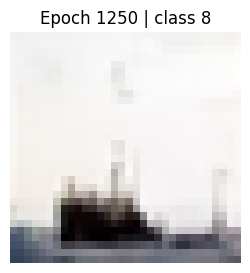

Epoch 1251/2000
------------------
Training Loss: 0.04781

Epoch 1252/2000
------------------
Training Loss: 0.04807

Epoch 1253/2000
------------------
Training Loss: 0.04823

Epoch 1254/2000
------------------
Training Loss: 0.04791

Epoch 1255/2000
------------------
Training Loss: 0.04794

Epoch 1256/2000
------------------
Training Loss: 0.04766

Epoch 1257/2000
------------------
Training Loss: 0.04778

Epoch 1258/2000
------------------
Training Loss: 0.04847

Epoch 1259/2000
------------------
Training Loss: 0.04811

Epoch 1260/2000
------------------
Training Loss: 0.04734

Epoch 1261/2000
------------------
Training Loss: 0.04783

Epoch 1262/2000
------------------
Training Loss: 0.04805

Epoch 1263/2000
------------------
Training Loss: 0.04766

Epoch 1264/2000
------------------
Training Loss: 0.04732

Epoch 1265/2000
------------------
Training Loss: 0.04879

Epoch 1266/2000
------------------
Training Loss: 0.04762

Epoch 1267/2000
------------------
Training Loss: 0.0480

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

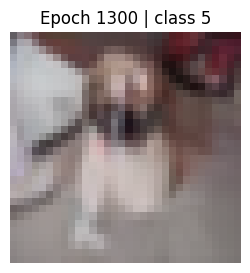

Epoch 1301/2000
------------------
Training Loss: 0.04798

Epoch 1302/2000
------------------
Training Loss: 0.04781

Epoch 1303/2000
------------------
Training Loss: 0.04770

Epoch 1304/2000
------------------
Training Loss: 0.04754

Epoch 1305/2000
------------------
Training Loss: 0.04762

Epoch 1306/2000
------------------
Training Loss: 0.04791

Epoch 1307/2000
------------------
Training Loss: 0.04781

Epoch 1308/2000
------------------
Training Loss: 0.04787

Epoch 1309/2000
------------------
Training Loss: 0.04817

Epoch 1310/2000
------------------
Training Loss: 0.04811

Epoch 1311/2000
------------------
Training Loss: 0.04775

Epoch 1312/2000
------------------
Training Loss: 0.04749

Epoch 1313/2000
------------------
Training Loss: 0.04770

Epoch 1314/2000
------------------
Training Loss: 0.04738

Epoch 1315/2000
------------------
Training Loss: 0.04717

Epoch 1316/2000
------------------
Training Loss: 0.04778

Epoch 1317/2000
------------------
Training Loss: 0.0477

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

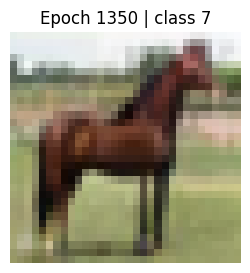

Epoch 1351/2000
------------------
Training Loss: 0.04776

Epoch 1352/2000
------------------
Training Loss: 0.04754

Epoch 1353/2000
------------------
Training Loss: 0.04796

Epoch 1354/2000
------------------
Training Loss: 0.04779

Epoch 1355/2000
------------------
Training Loss: 0.04783

Epoch 1356/2000
------------------
Training Loss: 0.04806

Epoch 1357/2000
------------------
Training Loss: 0.04817

Epoch 1358/2000
------------------
Training Loss: 0.04724

Epoch 1359/2000
------------------
Training Loss: 0.04777

Epoch 1360/2000
------------------
Training Loss: 0.04793

Epoch 1361/2000
------------------
Training Loss: 0.04725

Epoch 1362/2000
------------------
Training Loss: 0.04723

Epoch 1363/2000
------------------
Training Loss: 0.04802

Epoch 1364/2000
------------------
Training Loss: 0.04766

Epoch 1365/2000
------------------
Training Loss: 0.04698

Epoch 1366/2000
------------------
Training Loss: 0.04771

Epoch 1367/2000
------------------
Training Loss: 0.0473

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

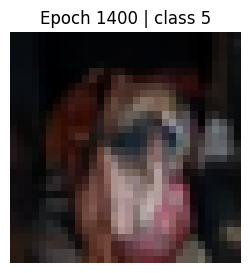

Epoch 1401/2000
------------------
Training Loss: 0.04764

Epoch 1402/2000
------------------
Training Loss: 0.04753

Epoch 1403/2000
------------------
Training Loss: 0.04779

Epoch 1404/2000
------------------
Training Loss: 0.04743

Epoch 1405/2000
------------------
Training Loss: 0.04731

Epoch 1406/2000
------------------
Training Loss: 0.04815

Epoch 1407/2000
------------------
Training Loss: 0.04744

Epoch 1408/2000
------------------
Training Loss: 0.04741

Epoch 1409/2000
------------------
Training Loss: 0.04716

Epoch 1410/2000
------------------
Training Loss: 0.04785

Epoch 1411/2000
------------------
Training Loss: 0.04794

Epoch 1412/2000
------------------
Training Loss: 0.04739

Epoch 1413/2000
------------------
Training Loss: 0.04740

Epoch 1414/2000
------------------
Training Loss: 0.04768

Epoch 1415/2000
------------------
Training Loss: 0.04744

Epoch 1416/2000
------------------
Training Loss: 0.04682

Epoch 1417/2000
------------------
Training Loss: 0.0472

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

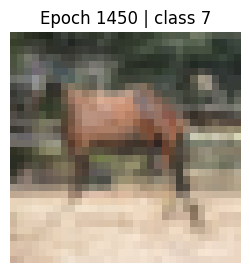

Epoch 1451/2000
------------------
Training Loss: 0.04756

Epoch 1452/2000
------------------
Training Loss: 0.04718

Epoch 1453/2000
------------------
Training Loss: 0.04695

Epoch 1454/2000
------------------
Training Loss: 0.04709

Epoch 1455/2000
------------------
Training Loss: 0.04778

Epoch 1456/2000
------------------
Training Loss: 0.04712

Epoch 1457/2000
------------------
Training Loss: 0.04714

Epoch 1458/2000
------------------
Training Loss: 0.04773

Epoch 1459/2000
------------------
Training Loss: 0.04746

Epoch 1460/2000
------------------
Training Loss: 0.04773

Epoch 1461/2000
------------------
Training Loss: 0.04685

Epoch 1462/2000
------------------
Training Loss: 0.04693

Epoch 1463/2000
------------------
Training Loss: 0.04790

Epoch 1464/2000
------------------
Training Loss: 0.04729

Epoch 1465/2000
------------------
Training Loss: 0.04723

Epoch 1466/2000
------------------
Training Loss: 0.04750

Epoch 1467/2000
------------------
Training Loss: 0.0469

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

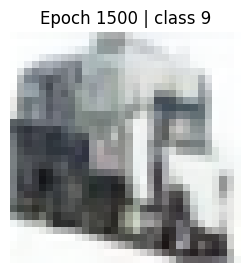

Epoch 1501/2000
------------------
Training Loss: 0.04711

Epoch 1502/2000
------------------
Training Loss: 0.04718

Epoch 1503/2000
------------------
Training Loss: 0.04684

Epoch 1504/2000
------------------
Training Loss: 0.04785

Epoch 1505/2000
------------------
Training Loss: 0.04685

Epoch 1506/2000
------------------
Training Loss: 0.04785

Epoch 1507/2000
------------------
Training Loss: 0.04714

Epoch 1508/2000
------------------
Training Loss: 0.04711

Epoch 1509/2000
------------------
Training Loss: 0.04691

Epoch 1510/2000
------------------
Training Loss: 0.04692

Epoch 1511/2000
------------------
Training Loss: 0.04705

Epoch 1512/2000
------------------
Training Loss: 0.04714

Epoch 1513/2000
------------------
Training Loss: 0.04747

Epoch 1514/2000
------------------
Training Loss: 0.04720

Epoch 1515/2000
------------------
Training Loss: 0.04694

Epoch 1516/2000
------------------
Training Loss: 0.04744

Epoch 1517/2000
------------------
Training Loss: 0.0475

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

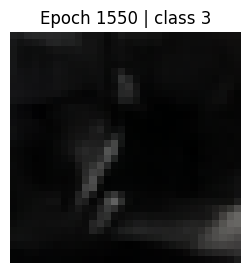

Epoch 1551/2000
------------------
Training Loss: 0.04655

Epoch 1552/2000
------------------
Training Loss: 0.04751

Epoch 1553/2000
------------------
Training Loss: 0.04729

Epoch 1554/2000
------------------
Training Loss: 0.04690

Epoch 1555/2000
------------------
Training Loss: 0.04733

Epoch 1556/2000
------------------
Training Loss: 0.04717

Epoch 1557/2000
------------------
Training Loss: 0.04765

Epoch 1558/2000
------------------
Training Loss: 0.04662

Epoch 1559/2000
------------------
Training Loss: 0.04738

Epoch 1560/2000
------------------
Training Loss: 0.04706

Epoch 1561/2000
------------------
Training Loss: 0.04703

Epoch 1562/2000
------------------
Training Loss: 0.04735

Epoch 1563/2000
------------------
Training Loss: 0.04739

Epoch 1564/2000
------------------
Training Loss: 0.04766

Epoch 1565/2000
------------------
Training Loss: 0.04704

Epoch 1566/2000
------------------
Training Loss: 0.04741

Epoch 1567/2000
------------------
Training Loss: 0.0477

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

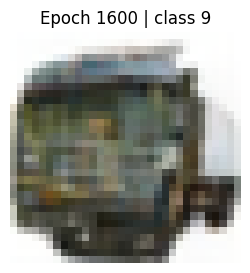

Epoch 1601/2000
------------------
Training Loss: 0.04728

Epoch 1602/2000
------------------
Training Loss: 0.04760

Epoch 1603/2000
------------------
Training Loss: 0.04731

Epoch 1604/2000
------------------
Training Loss: 0.04760

Epoch 1605/2000
------------------
Training Loss: 0.04728

Epoch 1606/2000
------------------
Training Loss: 0.04699

Epoch 1607/2000
------------------
Training Loss: 0.04757

Epoch 1608/2000
------------------
Training Loss: 0.04756

Epoch 1609/2000
------------------
Training Loss: 0.04641

Epoch 1610/2000
------------------
Training Loss: 0.04650

Epoch 1611/2000
------------------
Training Loss: 0.04662

Epoch 1612/2000
------------------
Training Loss: 0.04687

Epoch 1613/2000
------------------
Training Loss: 0.04745

Epoch 1614/2000
------------------
Training Loss: 0.04756

Epoch 1615/2000
------------------
Training Loss: 0.04701

Epoch 1616/2000
------------------
Training Loss: 0.04753

Epoch 1617/2000
------------------
Training Loss: 0.0464

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

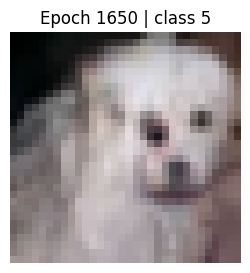

Epoch 1651/2000
------------------
Training Loss: 0.04745

Epoch 1652/2000
------------------
Training Loss: 0.04721

Epoch 1653/2000
------------------
Training Loss: 0.04623

Epoch 1654/2000
------------------
Training Loss: 0.04680

Epoch 1655/2000
------------------
Training Loss: 0.04702

Epoch 1656/2000
------------------
Training Loss: 0.04698

Epoch 1657/2000
------------------
Training Loss: 0.04752

Epoch 1658/2000
------------------
Training Loss: 0.04675

Epoch 1659/2000
------------------
Training Loss: 0.04639

Epoch 1660/2000
------------------
Training Loss: 0.04705

Epoch 1661/2000
------------------
Training Loss: 0.04590

Epoch 1662/2000
------------------
Training Loss: 0.04681

Epoch 1663/2000
------------------
Training Loss: 0.04664

Epoch 1664/2000
------------------
Training Loss: 0.04684

Epoch 1665/2000
------------------
Training Loss: 0.04679

Epoch 1666/2000
------------------
Training Loss: 0.04681

Epoch 1667/2000
------------------
Training Loss: 0.0471

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

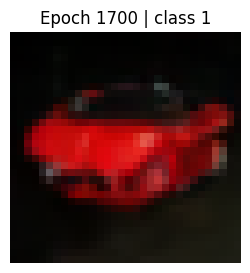

Epoch 1701/2000
------------------
Training Loss: 0.04695

Epoch 1702/2000
------------------
Training Loss: 0.04711

Epoch 1703/2000
------------------
Training Loss: 0.04689

Epoch 1704/2000
------------------
Training Loss: 0.04640

Epoch 1705/2000
------------------
Training Loss: 0.04680

Epoch 1706/2000
------------------
Training Loss: 0.04670

Epoch 1707/2000
------------------
Training Loss: 0.04629

Epoch 1708/2000
------------------
Training Loss: 0.04721

Epoch 1709/2000
------------------
Training Loss: 0.04638

Epoch 1710/2000
------------------
Training Loss: 0.04635

Epoch 1711/2000
------------------
Training Loss: 0.04660

Epoch 1712/2000
------------------
Training Loss: 0.04674

Epoch 1713/2000
------------------
Training Loss: 0.04624

Epoch 1714/2000
------------------
Training Loss: 0.04647

Epoch 1715/2000
------------------
Training Loss: 0.04642

Epoch 1716/2000
------------------
Training Loss: 0.04650

Epoch 1717/2000
------------------
Training Loss: 0.0468

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

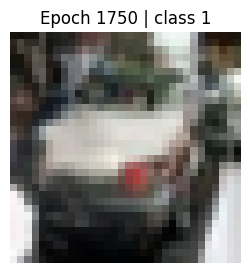

Epoch 1751/2000
------------------
Training Loss: 0.04631

Epoch 1752/2000
------------------
Training Loss: 0.04690

Epoch 1753/2000
------------------
Training Loss: 0.04667

Epoch 1754/2000
------------------
Training Loss: 0.04641

Epoch 1755/2000
------------------
Training Loss: 0.04690

Epoch 1756/2000
------------------
Training Loss: 0.04687

Epoch 1757/2000
------------------
Training Loss: 0.04647

Epoch 1758/2000
------------------
Training Loss: 0.04640

Epoch 1759/2000
------------------
Training Loss: 0.04707

Epoch 1760/2000
------------------
Training Loss: 0.04640

Epoch 1761/2000
------------------
Training Loss: 0.04672

Epoch 1762/2000
------------------
Training Loss: 0.04681

Epoch 1763/2000
------------------
Training Loss: 0.04616

Epoch 1764/2000
------------------
Training Loss: 0.04696

Epoch 1765/2000
------------------
Training Loss: 0.04704

Epoch 1766/2000
------------------
Training Loss: 0.04680

Epoch 1767/2000
------------------
Training Loss: 0.0469

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

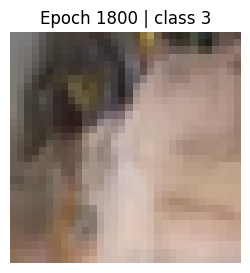

Epoch 1801/2000
------------------
Training Loss: 0.04611

Epoch 1802/2000
------------------
Training Loss: 0.04661

Epoch 1803/2000
------------------
Training Loss: 0.04574

Epoch 1804/2000
------------------
Training Loss: 0.04646

Epoch 1805/2000
------------------
Training Loss: 0.04641

Epoch 1806/2000
------------------
Training Loss: 0.04619

Epoch 1807/2000
------------------
Training Loss: 0.04587

Epoch 1808/2000
------------------
Training Loss: 0.04586

Epoch 1809/2000
------------------
Training Loss: 0.04658

Epoch 1810/2000
------------------
Training Loss: 0.04715

Epoch 1811/2000
------------------
Training Loss: 0.04652

Epoch 1812/2000
------------------
Training Loss: 0.04610

Epoch 1813/2000
------------------
Training Loss: 0.04641

Epoch 1814/2000
------------------
Training Loss: 0.04623

Epoch 1815/2000
------------------
Training Loss: 0.04598

Epoch 1816/2000
------------------
Training Loss: 0.04675

Epoch 1817/2000
------------------
Training Loss: 0.0465

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

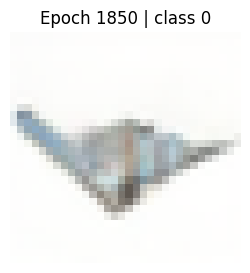

Epoch 1851/2000
------------------
Training Loss: 0.04609

Epoch 1852/2000
------------------
Training Loss: 0.04601

Epoch 1853/2000
------------------
Training Loss: 0.04688

Epoch 1854/2000
------------------
Training Loss: 0.04587

Epoch 1855/2000
------------------
Training Loss: 0.04620

Epoch 1856/2000
------------------
Training Loss: 0.04676

Epoch 1857/2000
------------------
Training Loss: 0.04646

Epoch 1858/2000
------------------
Training Loss: 0.04616

Epoch 1859/2000
------------------
Training Loss: 0.04630

Epoch 1860/2000
------------------
Training Loss: 0.04621

Epoch 1861/2000
------------------
Training Loss: 0.04654

Epoch 1862/2000
------------------
Training Loss: 0.04687

Epoch 1863/2000
------------------
Training Loss: 0.04600

Epoch 1864/2000
------------------
Training Loss: 0.04637

Epoch 1865/2000
------------------
Training Loss: 0.04671

Epoch 1866/2000
------------------
Training Loss: 0.04622

Epoch 1867/2000
------------------
Training Loss: 0.0464

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

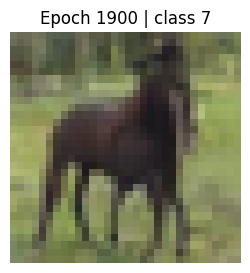

Epoch 1901/2000
------------------
Training Loss: 0.04585

Epoch 1902/2000
------------------
Training Loss: 0.04601

Epoch 1903/2000
------------------
Training Loss: 0.04633

Epoch 1904/2000
------------------
Training Loss: 0.04615

Epoch 1905/2000
------------------
Training Loss: 0.04630

Epoch 1906/2000
------------------
Training Loss: 0.04703

Epoch 1907/2000
------------------
Training Loss: 0.04629

Epoch 1908/2000
------------------
Training Loss: 0.04597

Epoch 1909/2000
------------------
Training Loss: 0.04570

Epoch 1910/2000
------------------
Training Loss: 0.04666

Epoch 1911/2000
------------------
Training Loss: 0.04616

Epoch 1912/2000
------------------
Training Loss: 0.04611

Epoch 1913/2000
------------------
Training Loss: 0.04582

Epoch 1914/2000
------------------
Training Loss: 0.04652

Epoch 1915/2000
------------------
Training Loss: 0.04653

Epoch 1916/2000
------------------
Training Loss: 0.04628

Epoch 1917/2000
------------------
Training Loss: 0.0465

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

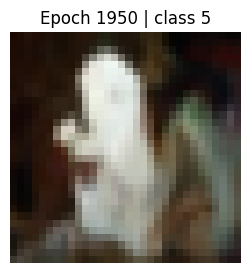

Epoch 1951/2000
------------------
Training Loss: 0.04630

Epoch 1952/2000
------------------
Training Loss: 0.04637

Epoch 1953/2000
------------------
Training Loss: 0.04657

Epoch 1954/2000
------------------
Training Loss: 0.04634

Epoch 1955/2000
------------------
Training Loss: 0.04631

Epoch 1956/2000
------------------
Training Loss: 0.04657

Epoch 1957/2000
------------------
Training Loss: 0.04607

Epoch 1958/2000
------------------
Training Loss: 0.04598

Epoch 1959/2000
------------------
Training Loss: 0.04615

Epoch 1960/2000
------------------
Training Loss: 0.04599

Epoch 1961/2000
------------------
Training Loss: 0.04608

Epoch 1962/2000
------------------
Training Loss: 0.04583

Epoch 1963/2000
------------------
Training Loss: 0.04605

Epoch 1964/2000
------------------
Training Loss: 0.04662

Epoch 1965/2000
------------------
Training Loss: 0.04616

Epoch 1966/2000
------------------
Training Loss: 0.04649

Epoch 1967/2000
------------------
Training Loss: 0.0464

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

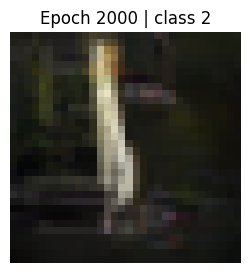

In [ ]:
# TRAINING
epochs = 2000
num_classes = len(train_dataset.classes) #10 classes
in_channels = 3
dataset = "CIFAR10"

if resume_training == True:
  start_epoch = 2000
else:
  start_epoch = 0

print(f"Training on {dataset}, for {epochs} epochs, with the following number of classes: {num_classes}")

class_free_dropout = 0.2
guidance_scale = 2.5

loss_hist = []
imgs_list = []

torch.set_float32_matmul_precision('high')
model.compile()

# Extract betas, alphas, alpha_bars
betas, alphas, alpha_bars = schedule()

for epoch in tqdm(range(start_epoch, epochs)):
  print(f"Epoch {epoch+1}/{epochs}\n------------------")

  train_loss = 0
  model.train()

  for batch, (images, labels) in enumerate(train_dataloader):

    images = images.to(device)
    labels = labels.to(device)

    batch_size = images.shape[0]

    # Extract random noise steps between 0-1000
    t = torch.randint(0, TIMESTEPS, (batch_size, ), device = device).long()

    # Forward diffusion - starting from image and random time t extract images with added noise at that timestep t
    noisy_images, noise = batched_diffusion_kernel(x_not = images, t = t, alpha_bars = alpha_bars)

    # Create a drop mask - NEW LINES
    drop_mask = torch.rand(batch_size, device = device) < class_free_dropout
    c_input = labels.clone()
    c_input[drop_mask] = -1 # null class "-1"

    pred_noise = model(noisy_images, time = t, c = c_input)

    # Compute Loss and optimize
    loss = loss_fn(pred_noise, noise)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
    optimizer.step()

  train_loss = train_loss / len(train_dataloader)

  loss_hist.append(train_loss)
  print(f"Training Loss: {train_loss:.5f}\n")

  if (epoch+1) % 50 == 0:
    model.eval()
    with torch.inference_mode():
      c = torch.randint(low = 0, high = num_classes, size = (1,), device = device)
      generated_img, _ = generating_loop(model,
                                         TIMESTEPS,
                                         img_shape = (1, in_channels, 32, 32),
                                         c = c,
                                         guidance_scale = guidance_scale)
      imgs_list.append(generated_img)

      # Plot images
      plt.figure(figsize=(3, 3))
      plt.imshow(generated_img)
      plt.axis("off")
      plt.title(f"Epoch {epoch+1} | class {c.item()}")
      plt.show()

  if (epoch+1)%100 == 0:
    data = Path("data")
    save_path = data / "checkpoints"
    save_model = save_path / f"cross_attention_{dataset}_checkpoint_{epoch+1}epochs.pt"
    save_optimizer = save_path / f"cross_attention_{dataset}_optimizer_{epoch+1}epochs.pt"
    if not save_path.exists():
      save_path.mkdir(parents = True, exist_ok = True)
    torch.save(obj = model.state_dict(), f = save_model)
    torch.save(obj = optimizer.state_dict(), f = save_optimizer)


In [ ]:
# Extract labels and turn them into dict
class_labels = train_dataset.classes
class_dict = {k: v for k, v in enumerate(class_labels)}
class_dict

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

In [ ]:
# Generate Image
class_key = 9
with torch.inference_mode():
  model.eval()
  img_gen, img_steps = generating_loop(model = model,
                                       timesteps = 1000,
                                       img_shape = (1,3,32,32),
                                       save_steps = True,
                                       c = torch.tensor([class_key]).to(device),
                                       guidance_scale = 3)

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

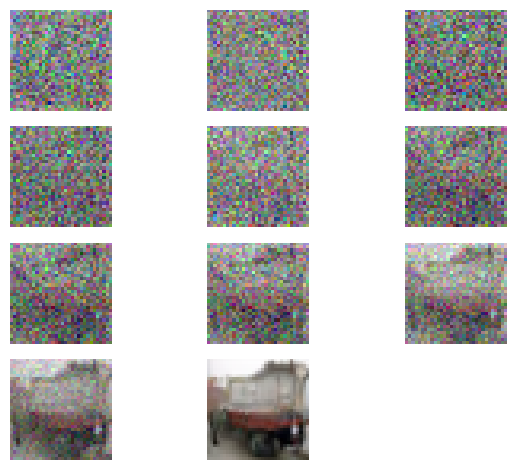

In [ ]:
# Plot denoising steps until convergence
for i, im in enumerate(img_steps):
    plt.subplot(4, 3, i + 1)

    im = im.detach().cpu()
    im = im.permute(1, 2, 0)

    im_min = im.min()
    im_max = im.max()
    im = (im - im_min) / (im_max - im_min + 1e-8)

    plt.imshow(im)
    plt.axis(False)

plt.tight_layout()

In [ ]:
range(num_classes)

range(0, 10)

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

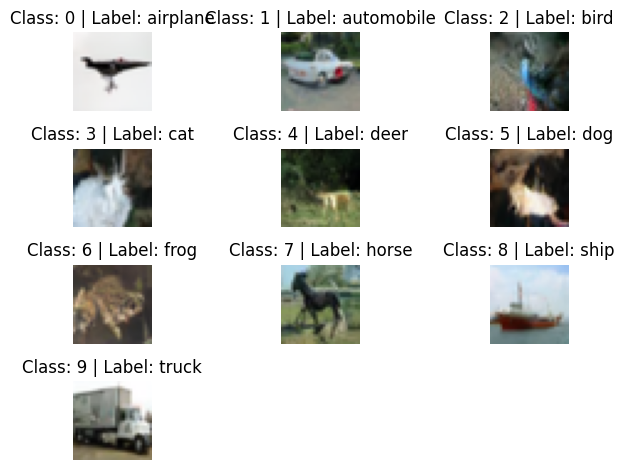

In [ ]:
img_list = []
for l in range(num_classes):
  # Generate Image
  with torch.inference_mode():
    model.eval()
    img_gen, img_steps = generating_loop(model = model,
                                        timesteps = 1000,
                                        img_shape = (1,3,32,32),
                                        save_steps = True,
                                        c = torch.tensor([l]).to(device),
                                        guidance_scale = 3)
    img_list.append(img_gen)

for i, img in enumerate(img_list):
  plt.subplot(4,3, i+1)
  plt.imshow(img)
  plt.axis(False)
  plt.title(f"Class: {i} | Label: {class_labels[i]}")
plt.tight_layout()

## Loading and Testing model

DDIM Reverse Process for 100 timesteps:   0%|          | 0/100 [00:00<?, ?it/s]

After clamping: x min: -0.603074312210083 | x max: -0.4517645239830017 | xstd: 0.028514914214611053 | x mean: -0.5169329643249512 | x shape: torch.Size([1, 3, 32, 32])
shape after permutation and unsqueeze: torch.Size([32, 32, 3])


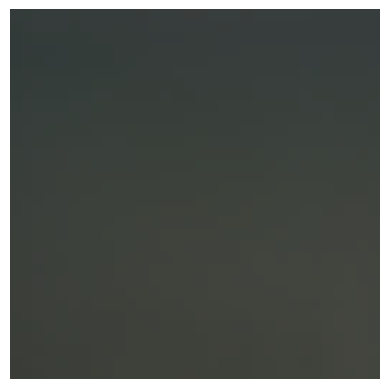

In [ ]:
from torch.serialization import MAP_LOCATION
data_path = Path("data")
model_path = data_path / "cross_attention_CIFAR10_checkpoint_2000epochs.pt"

model = ClassConditionedUNet(input_dim = 64, channels = 3, num_classes = 10, groupnorm_groups = 8).to(device)
model.load_state_dict(state_dict = torch.load(model_path, map_location = device))

c = 1
img, gen_steps = ddim_sampling_loop(model = model,
                                    timesteps = 1000,
                                    sampling_timesteps = 100,
                                    img_shape = (1,3,32,32),
                                    label = torch.tensor([c], dtype = torch.long),
                                    save_steps = True,
                                    guidance_scale = 3,
                                    eta = 0.6)

plt.imshow(img)
plt.axis(False);

DDIM Reverse Process for 200 timesteps:   0%|          | 0/200 [00:00<?, ?it/s]

After clamping: x min: -0.8695724606513977 | x max: 0.8855719566345215 | xstd: 0.3250850439071655 | x mean: -0.0617719404399395 | x shape: torch.Size([1, 3, 32, 32])
shape after permutation and unsqueeze: torch.Size([32, 32, 3])


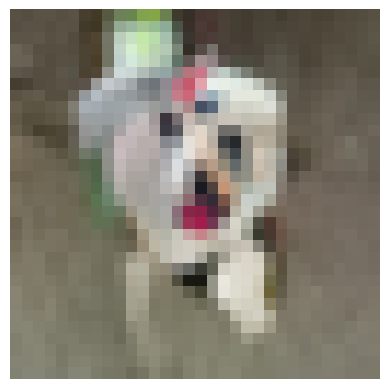

In [ ]:
c = 5
img, gen_steps = ddim_sampling_loop(model = model,
                                    timesteps = 1000,
                                    sampling_timesteps = 200,
                                    img_shape = (1,3,32,32),
                                    label = torch.tensor([c], dtype = torch.long),
                                    save_steps = True,
                                    guidance_scale = 20,
                                    eta = 0.8)

plt.imshow(img)
plt.axis(False);

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

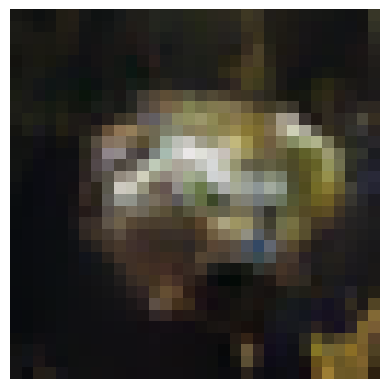

In [ ]:
model.eval()
sample, img_steps= generating_loop(model = model,
                                    timesteps = 1000,
                                    img_shape = (1,3,32,32),
                                    save_steps = True,
                                    c = torch.tensor([6], dtype = torch.long).to(device),
                                    guidance_scale = 2.5)

plt.imshow(sample)
plt.axis(False);

## EMA - Exponential Moving Average

In [ ]:
class EMA:
  def __init__(self, model, decay = 0.999):
    self.model = model
    self.decay = decay
    self.shadow = {}
    self.backup = {}

    for name, param in model.named_parameters():
      if param.requires_grad:
        self.shadow[name] = param.data.clone()

  def update(self):
    for name, param in self.model.named_parameters():
      if param.requires_grad:
        self.shadow[name].data = self.decay * self.shadow[name].data + (1 - self.decay) * param.data

  def apply_shadow(self):
    for name, param in self.model.named_parameters():
      if param.requires_grad:
        self.backup[name] = param.data.clone()
        param.data = self.shadow[name].data

  def restore(self):
    for name, param in self.model.named_parameters():
      if param.requires_grad:
        param.data = self.backup[name].data

  def state_dict(self):
    return self.shadow

  def load_state_dict(self, state_dict):
    self.shadow = state_dict

## V-Prediction

Given:
$$x_t = \alpha_t*x_0 + \sigma_t * \epsilon = \sqrt{\bar\alpha_{t}}*x_0 + \sqrt{1-\bar\alpha_{t}}*\epsilon$$

We know that *velocity* is:
$$v_t = \alpha_t*\epsilon - \sigma_t * x_0 = \sqrt{\bar\alpha_{t}}*\epsilon - \sqrt{1-\bar\alpha_{t}}*x_0$$

We can then derive $x_0$ and $\epsilon$:
$$x_0 = \sqrt{\bar\alpha_{t}}*x_t - \sqrt{1-\bar\alpha_{t}}*v_t$$
and
$$\epsilon = \sqrt{\bar\alpha_{t}}*v_t + \sqrt{1-\bar\alpha_{t}}*x_t$$

In [ ]:
def v_pred_extract(v_pred, x_t, alpha_bar_batched):
  """Extract x_0, epsilon from the velocity v"""
  x_0 = torch.sqrt(alpha_bar_batched)*x_t - torch.sqrt(1-alpha_bar_batched)*v_pred
  epsilon = torch.sqrt(alpha_bar_batched)*v_pred + torch.sqrt(1-alpha_bar_batched)*x_t
  return x_0, epsilon

## Training Function
Used for repeatable training

### Checkpoint Function

In [ ]:
import datetime
from pathlib import Path

def save_checkpoint(name, checkpoint, checkpoint_path):
  checkpoint_path = Path(checkpoint_path)

  if not checkpoint_path.exists():
    checkpoint_path.mkdir(parents = True, exist_ok = True)

  date = datetime.datetime.now()
  date = "_".join(date.strftime("%c").strip().split())

  save_path = checkpoint_path / f"{date}_{name}"

  if not (name.endswith(".pt") or name.endswith(".pth")):
    save_path = save_path + ".pt"

  print(f"[INFO] Saving {save_path}...")
  torch.save(obj = checkpoint, f = save_path)
  print(f"[INFO] Checkpoint saved! :)")

### Evaluate and generate function

In [ ]:
def get_sample_img(model, img_shape, timesteps = 1000, sampling_timesteps = 300, pred_type = 'v', c = 3, sampler = 'ddpm', guidance_scale = 2.5, eta = 0.8, plot_img = True, save_steps = True, epoch = None, seed = None):
  if seed is not None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

  device = next(model.parameters()).device
  model.eval()

  if isinstance(c, int):
    c = torch.tensor([c], dtype = torch.long, device = device)

  with torch.inference_mode():
    if sampler == 'ddpm':
      generated_img, img_steps = generating_loop_with_pred_type(model = model,
                                                                timesteps = timesteps,
                                                                img_shape = img_shape,
                                                                c = c,
                                                                pred_type = pred_type,
                                                                save_steps = save_steps,
                                                                guidance_scale = guidance_scale)
    elif sampler == 'ddim':
      generated_img, img_steps = ddim_sampling_loop_with_pred_type(model = model,
                                                                   timesteps = timesteps,
                                                                   sampling_timesteps = sampling_timesteps,
                                                                   img_shape = img_shape,
                                                                   c = c,
                                                                   pred_type = pred_type,
                                                                   save_steps = save_steps,
                                                                   guidance_scale = guidance_scale,
                                                                   eta = eta)

  if plot_img == True:
    plt.figure(figsize = (3,3))
    plt.imshow(generated_img)
    plt.axis(False)
    if epoch is not None:
      title = f"Epoch: {epoch+1} | Class: {c.item()}"
    else:
      title = f"Class: {c.item()}"
    plt.title(title)
    plt.show()

  return generated_img, img_steps


### Training Function

In [ ]:
def train(model,
          train_dataloader,
          epochs,
          device,
          pred_type = 'v',
          lr = 3e-4,
          class_free_dropout = 0.2,
          guidance_scale = 2.5,
          ema_decay = 0.999,
          timesteps = 1000,
          optim = "adam",
          checkpoint_path = None,
          save_path = None,
          load_checkpoint = False):
  valid_pred_type =['epsilon', 'x_0', 'v']

  if pred_type not in valid_pred_type:
    raise ValueError(f"Pred_type must be one of {valid_pred_type}, got {pred_type} instead")

  model = model.to(device)

  starting_epoch = 0
  loss_hist = []

  checkpoint = {}

  # Create optimizer
  if optim == "adam":
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
  elif optim == "adamw":
    optimizer = torch.optim.AdamW(params = model.parameters(), lr = lr, weight_decay = 0.01)
  else:
    raise ValueError(f"Optimizer must be either Adam or AdamW, got {optim} instead")

  # Create loss_fn
  loss_fn = torch.nn.MSELoss()

  # EMA
  ema = EMA(model = model, decay = ema_decay)

  # Noise Schedule
  schedule = DiffusionSchedule(timesteps = timesteps, schedule = 'cosine', device = device)
  betas, alphas, alpha_bars = schedule()

  # Load checkpoint if exists
  if load_checkpoint == True:
    checkpoint = torch.load(checkpoint_path, map_location = device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    ema.load_state_dict(checkpoint['ema_state_dict'])

    starting_epoch = checkpoint['epoch']+1
    pred_type = checkpoint['pred_type']
    loss_hist = checkpoint['loss_hist']

    class_free_dropout = checkpoint['class_free_dropout']
    guidance_scale = checkpoint['guidance_scale']

  # Compile model for faster training
  torch.set_float32_matmul_precision('high')
  model.compile()

  for epoch in tqdm(range(starting_epoch, epochs)):
    print(f"Epoch {epoch+1}/{epochs}\n------------------")
    model.train()
    train_loss = 0.0

    for batch, (images, labels) in enumerate(train_dataloader):
      images = images.to(device)
      labels = labels.to(device)

      batch_size = images.shape[0]

      # Extract random noise steps between 0-1000
      t = torch.randint(0, timesteps, (batch_size, ), device = device).long()

      ### FORWARD DIFFUSION
      noisy_images, noise = batched_diffusion_kernel(x_not = images,
                                                     t = t,
                                                     alpha_bars = alpha_bars)

      ### Drop Mask for CFG
      drop_mask = torch.rand(batch_size, device = device) < class_free_dropout
      c_input = labels.clone()
      c_input[drop_mask] = -1 # null class token is identified with '-1'

      # Make a prediction
      pred_target = model(noisy_images, time = t, c = c_input)

      # Pick loss based on input
      if pred_type == 'v':
        alpha_bars_batched = extract(alpha_bars, t, images.shape)
        target = torch.sqrt(alpha_bars_batched)*noise - torch.sqrt(1-alpha_bars_batched)*images
      elif pred_type == 'epsilon':
        target = noise
      elif pred_type == 'x0':
        target = images
      else:
        raise SyntaxError(f"{pred_type} loss not supported, use: v, epsilon, x0")

      # Compute loss and optimize
      loss = loss_fn(pred_target, target)
      train_loss += loss.item()

      optimizer.zero_grad()
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 10.0)
      optimizer.step()
      ema.update()

    train_loss /= len(train_dataloader)
    loss_hist.append(train_loss)

    print(f"Training Loss: {train_loss:.5f}\n")

    if (epoch+1)%50 == 0:
      model.eval()

      # Apply ema weights
      ema.apply_shadow()

      with torch.inference_mode():
        get_sample_img(model = model,
                      img_shape = (1,3,32,32),
                      timesteps = timesteps,
                      pred_type = pred_type,
                      c = 3,
                      sampler = 'ddpm',
                      guidance_scale = guidance_scale,
                      plot_img = True,
                      save_steps = False,
                      epoch = epoch+1,
                      seed = 42)

      # Restore model's weights
      ema.restore()

    # Create a checkpoint and save it
    checkpoint['model_state_dict'] = model.state_dict()
    checkpoint['optimizer_state_dict'] = optimizer.state_dict()
    checkpoint['ema_state_dict'] = ema.state_dict()
    checkpoint['epoch'] = epoch
    checkpoint['pred_type'] = pred_type
    checkpoint['loss_hist'] = loss_hist
    checkpoint['class_free_dropout'] = class_free_dropout
    checkpoint['guidance_scale'] = guidance_scale

    if ((epoch+1)%200 == 0) or ((epoch+1) == epochs):
      save_checkpoint(name = f"checkpoint_{epoch+1}epoch_{lr}_lr_{pred_type}_pred_type.pt",
                      checkpoint = checkpoint,
                      checkpoint_path = save_path)

  return loss_hist

#### Train Our Model

In [ ]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# Device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}!")

# Dataloader hyperparameters
BATCH_SIZE = 128
NUM_WORKERS = os.cpu_count()

# Model hyperparameters
IN_CHANNELS = 3
INPUT_DIM = 64
GROUPNORM_GROUPS = 32
NUM_CLASSES = 10

# Paths
data_path = Path("data")
SAVE_PATH = data_path / "checkpoint"
CHECKPOINT_PATH = "/content/data/Wed_May_13_22_48_51_2026_checkpoint_1800epoch_0.0003_lr_v_pred_type.pt"
LOAD_CHECKPOINT = True

# Training
EPOCHS = 2000
PRED_TYPE = 'v'
LR = 3e-4
CLASS_FREE_DROPOUT = 0.2
GUIDANCE_SCALE = 2.5
EMA_DECAY = 0.999
TIMESTEPS = 1000
OPTIM = 'adamw'



train_transform = transforms.Compose([
                        transforms.Resize((32,32)),
                        transforms.RandomHorizontalFlip(),
                        transforms.ToTensor(),
                        transforms.Lambda(lambda t: (t*2)-1)])


train_dataset  = CIFAR10(root = data_path,
                       train = True,
                       transform = train_transform,
                       download = True)

train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS,
                              pin_memory = True)




# Instantiate new model
model = ClassConditionedUNet(input_dim = INPUT_DIM, channels = IN_CHANNELS, num_classes = NUM_CLASSES, groupnorm_groups = GROUPNORM_GROUPS).to(device)

Running on: cuda!


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1801/2000
------------------


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Training Loss: 0.10414

Epoch 1802/2000
------------------
Training Loss: 0.10392

Epoch 1803/2000
------------------
Training Loss: 0.10385

Epoch 1804/2000
------------------
Training Loss: 0.10330

Epoch 1805/2000
------------------
Training Loss: 0.10408

Epoch 1806/2000
------------------
Training Loss: 0.10411

Epoch 1807/2000
------------------
Training Loss: 0.10361

Epoch 1808/2000
------------------
Training Loss: 0.10448

Epoch 1809/2000
------------------
Training Loss: 0.10324

Epoch 1810/2000
------------------
Training Loss: 0.10391

Epoch 1811/2000
------------------
Training Loss: 0.10409

Epoch 1812/2000
------------------
Training Loss: 0.10410

Epoch 1813/2000
------------------
Training Loss: 0.10488

Epoch 1814/2000
------------------
Training Loss: 0.10437

Epoch 1815/2000
------------------
Training Loss: 0.10358

Epoch 1816/2000
------------------
Training Loss: 0.10310

Epoch 1817/2000
------------------
Training Loss: 0.10378

Epoch 1818/2000
----------------

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


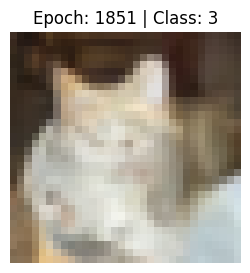

Epoch 1851/2000
------------------
Training Loss: 0.10202

Epoch 1852/2000
------------------
Training Loss: 0.10082

Epoch 1853/2000
------------------
Training Loss: 0.09983

Epoch 1854/2000
------------------
Training Loss: 0.09950

Epoch 1855/2000
------------------
Training Loss: 0.09878

Epoch 1856/2000
------------------
Training Loss: 0.09905

Epoch 1857/2000
------------------
Training Loss: 0.09774

Epoch 1858/2000
------------------
Training Loss: 0.09739

Epoch 1859/2000
------------------
Training Loss: 0.09744

Epoch 1860/2000
------------------
Training Loss: 0.09772

Epoch 1861/2000
------------------
Training Loss: 0.09659

Epoch 1862/2000
------------------
Training Loss: 0.09700

Epoch 1863/2000
------------------
Training Loss: 0.09694

Epoch 1864/2000
------------------
Training Loss: 0.09672

Epoch 1865/2000
------------------
Training Loss: 0.09628

Epoch 1866/2000
------------------
Training Loss: 0.09633

Epoch 1867/2000
------------------
Training Loss: 0.0965

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

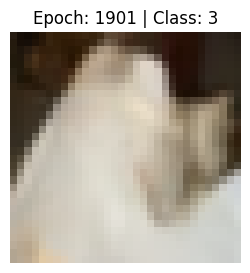

Epoch 1901/2000
------------------
Training Loss: 0.09418

Epoch 1902/2000
------------------
Training Loss: 0.09371

Epoch 1903/2000
------------------
Training Loss: 0.09371

Epoch 1904/2000
------------------
Training Loss: 0.09377

Epoch 1905/2000
------------------
Training Loss: 0.09356

Epoch 1906/2000
------------------
Training Loss: 0.09435

Epoch 1907/2000
------------------
Training Loss: 0.09339

Epoch 1908/2000
------------------
Training Loss: 0.09337

Epoch 1909/2000
------------------
Training Loss: 0.09348

Epoch 1910/2000
------------------
Training Loss: 0.09407

Epoch 1911/2000
------------------
Training Loss: 0.09310

Epoch 1912/2000
------------------
Training Loss: 0.09356

Epoch 1913/2000
------------------
Training Loss: 0.09366

Epoch 1914/2000
------------------
Training Loss: 0.09365

Epoch 1915/2000
------------------
Training Loss: 0.09332

Epoch 1916/2000
------------------
Training Loss: 0.09345

Epoch 1917/2000
------------------
Training Loss: 0.0937

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

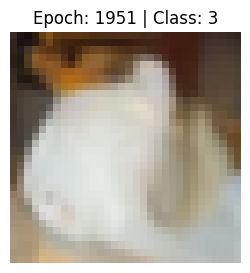

Epoch 1951/2000
------------------
Training Loss: 0.09289

Epoch 1952/2000
------------------
Training Loss: 0.09267

Epoch 1953/2000
------------------
Training Loss: 0.09261

Epoch 1954/2000
------------------
Training Loss: 0.09266

Epoch 1955/2000
------------------
Training Loss: 0.09254

Epoch 1956/2000
------------------
Training Loss: 0.09328

Epoch 1957/2000
------------------
Training Loss: 0.09244

Epoch 1958/2000
------------------
Training Loss: 0.09237

Epoch 1959/2000
------------------
Training Loss: 0.09256

Epoch 1960/2000
------------------
Training Loss: 0.09313

Epoch 1961/2000
------------------
Training Loss: 0.09223

Epoch 1962/2000
------------------
Training Loss: 0.09269

Epoch 1963/2000
------------------
Training Loss: 0.09284

Epoch 1964/2000
------------------
Training Loss: 0.09278

Epoch 1965/2000
------------------
Training Loss: 0.09262

Epoch 1966/2000
------------------
Training Loss: 0.09266

Epoch 1967/2000
------------------
Training Loss: 0.0930

Generating sample in a total of 1000 timesteps:   0%|          | 0/1000 [00:00<?, ?it/s]

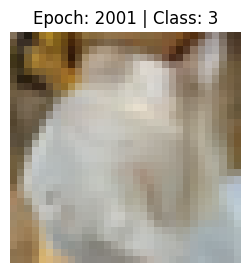

[INFO] Saving data/checkpoint/Fri_May_15_13:22:22_2026_checkpoint_2000epoch_0.0003_lr_v_pred_type.pt...
[INFO] Checkpoint saved! :)


In [ ]:
loss_hist = train(model = model,
                  train_dataloader = train_dataloader,
                  epochs = EPOCHS,
                  device = device,
                  pred_type = PRED_TYPE,
                  lr = LR,
                  class_free_dropout = CLASS_FREE_DROPOUT,
                  guidance_scale = GUIDANCE_SCALE,
                  ema_decay = EMA_DECAY,
                  timesteps = TIMESTEPS,
                  optim = OPTIM,
                  checkpoint_path = CHECKPOINT_PATH,
                  save_path = SAVE_PATH,
                  load_checkpoint = LOAD_CHECKPOINT)

#### Testing out the model

In [ ]:
model_path = Path("/content/drive/MyDrive/Colab Notebooks/Stable Diffusion/Models/Fri_May_15_13_22_22_2026_checkpoint_2000epoch_0.0003_lr_v_pred_type.pt")
checkpoint = torch.load(model_path, map_location = device)

loaded_model = ClassConditionedUNet(input_dim = 64, channels = 3, num_classes = 10, groupnorm_groups = 32).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

loaded_model

ClassConditionedUNet(
  (class_embedding): Embedding(10, 256)
  (class_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (unet): DenoisingUNet(
    (initial_conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    (time_mlp): Sequential(
      (0): SinPositionalEmbedding()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (downs): ModuleList(
      (0): ModuleList(
        (0-1): 2 x ResnetBlock(
          (conv1): ConvBlock(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): GroupNorm(32, 64, eps=1e-05, affine=True)
            (activation): SiLU()
          )
          (conv2): ConvBlock(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

DDIM Reverse Process for 300 timesteps:   0%|          | 0/300 [00:00<?, ?it/s]

After clamping: x min: -0.9973060488700867 | x max: 1.0 | xstd: 0.7050523161888123 | x mean: 0.07227463275194168 | x shape: torch.Size([1, 3, 32, 32])


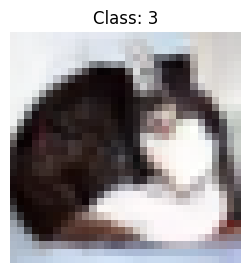

In [ ]:
# Prediction with model without EMA weights
c = 3
seed = 696969

with torch.inference_mode():
  get_sample_img(model = loaded_model,
                img_shape = (1,3,32,32),
                timesteps = 1000,
                sampling_timesteps = 300,
                pred_type = 'v',
                c = c,
                sampler = 'ddim',
                guidance_scale = 2.5,
                eta = 0.8,
                plot_img = True,
                save_steps = False,
                epoch = None,
                seed = seed)

DDIM Reverse Process for 300 timesteps:   0%|          | 0/300 [00:00<?, ?it/s]

After clamping: x min: -1.0 | x max: 1.0 | xstd: 0.8041149973869324 | x mean: 0.23147261142730713 | x shape: torch.Size([1, 3, 32, 32])


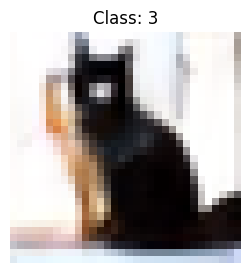

In [ ]:
# Load ema weights
loaded_ema = EMA(loaded_model, decay = 0.999)
loaded_ema.load_state_dict(checkpoint['ema_state_dict'])
loaded_ema.apply_shadow()

# Predict with model with EMA shadow
with torch.inference_mode():
  get_sample_img(model = loaded_model,
                img_shape = (1,3,32,32),
                timesteps = 1000,
                sampling_timesteps = 300,
                pred_type = 'v',
                c = c,
                sampler = 'ddim',
                guidance_scale = 5,
                eta = 0.8,
                plot_img = True,
                save_steps = False,
                epoch = None,
                seed = seed)
loaded_ema.restore()

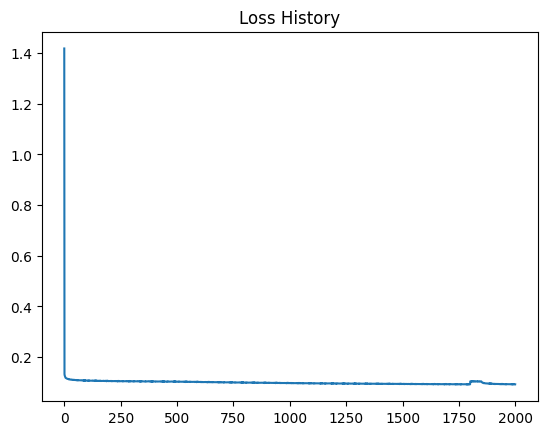

In [ ]:
loss_hist_loaded = checkpoint['loss_hist']

plt.plot(range(len(loss_hist_loaded)), loss_hist_loaded)
plt.title("Loss History") ;

In [ ]:
import math
import torch
import matplotlib.pyplot as plt


def compare_normal_vs_ema(
    model,
    ema,
    get_sample_img,
    img_shape=(1, 3, 32, 32),
    timesteps=1000,
    sampling_timesteps=300,
    pred_type="v",
    sampler="ddim",
    guidance_scale=5,
    eta=0.8,
    seed=42,
):
    class_names = [
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck"
    ]

    num_classes = len(class_names)
    groups_per_row = 3
    cols = groups_per_row * 2
    rows = math.ceil(num_classes / groups_per_row)

    fig, axes = plt.subplots(
        nrows=rows,
        ncols=cols,
        figsize=(18, rows * 3)
    )

    axes = axes.reshape(rows, cols)

    for class_idx, class_name in enumerate(class_names):
        print(f"Generating class: {class_idx} | {num_classes-1}\n---------")
        row = class_idx // groups_per_row
        group_col = class_idx % groups_per_row
        col_left = group_col * 2
        col_right = col_left + 1

        c = torch.tensor([class_idx], device=next(model.parameters()).device)

        # normal model
        model.eval()
        img_normal, _ = get_sample_img(
            model=model,
            img_shape=img_shape,
            timesteps=timesteps,
            sampling_timesteps=sampling_timesteps,
            pred_type=pred_type,
            c=c,
            sampler=sampler,
            guidance_scale=guidance_scale,
            eta=eta,
            plot_img=False,
            save_steps=False,
            epoch=None,
            seed=seed,
        )

        # EMA model
        ema.apply_shadow()
        img_ema, _ = get_sample_img(
            model=model,
            img_shape=img_shape,
            timesteps=timesteps,
            sampling_timesteps=sampling_timesteps,
            pred_type=pred_type,
            c=c,
            sampler=sampler,
            guidance_scale=guidance_scale,
            eta=eta,
            plot_img=False,
            save_steps=False,
            epoch=None,
            seed=seed,
        )
        ema.restore()

        axes[row, col_left].imshow(img_normal)
        axes[row, col_left].set_title(f"{class_name}\nNo EMA")
        axes[row, col_left].axis("off")

        axes[row, col_right].imshow(img_ema)
        axes[row, col_right].set_title(f"{class_name}\nEMA")
        axes[row, col_right].axis("off")

    # hide unused subplot slots
    for idx in range(num_classes * 2, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

...

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

DDIM Reverse Process for 25 timesteps:   0%|          | 0/25 [00:00<?, ?it/s]

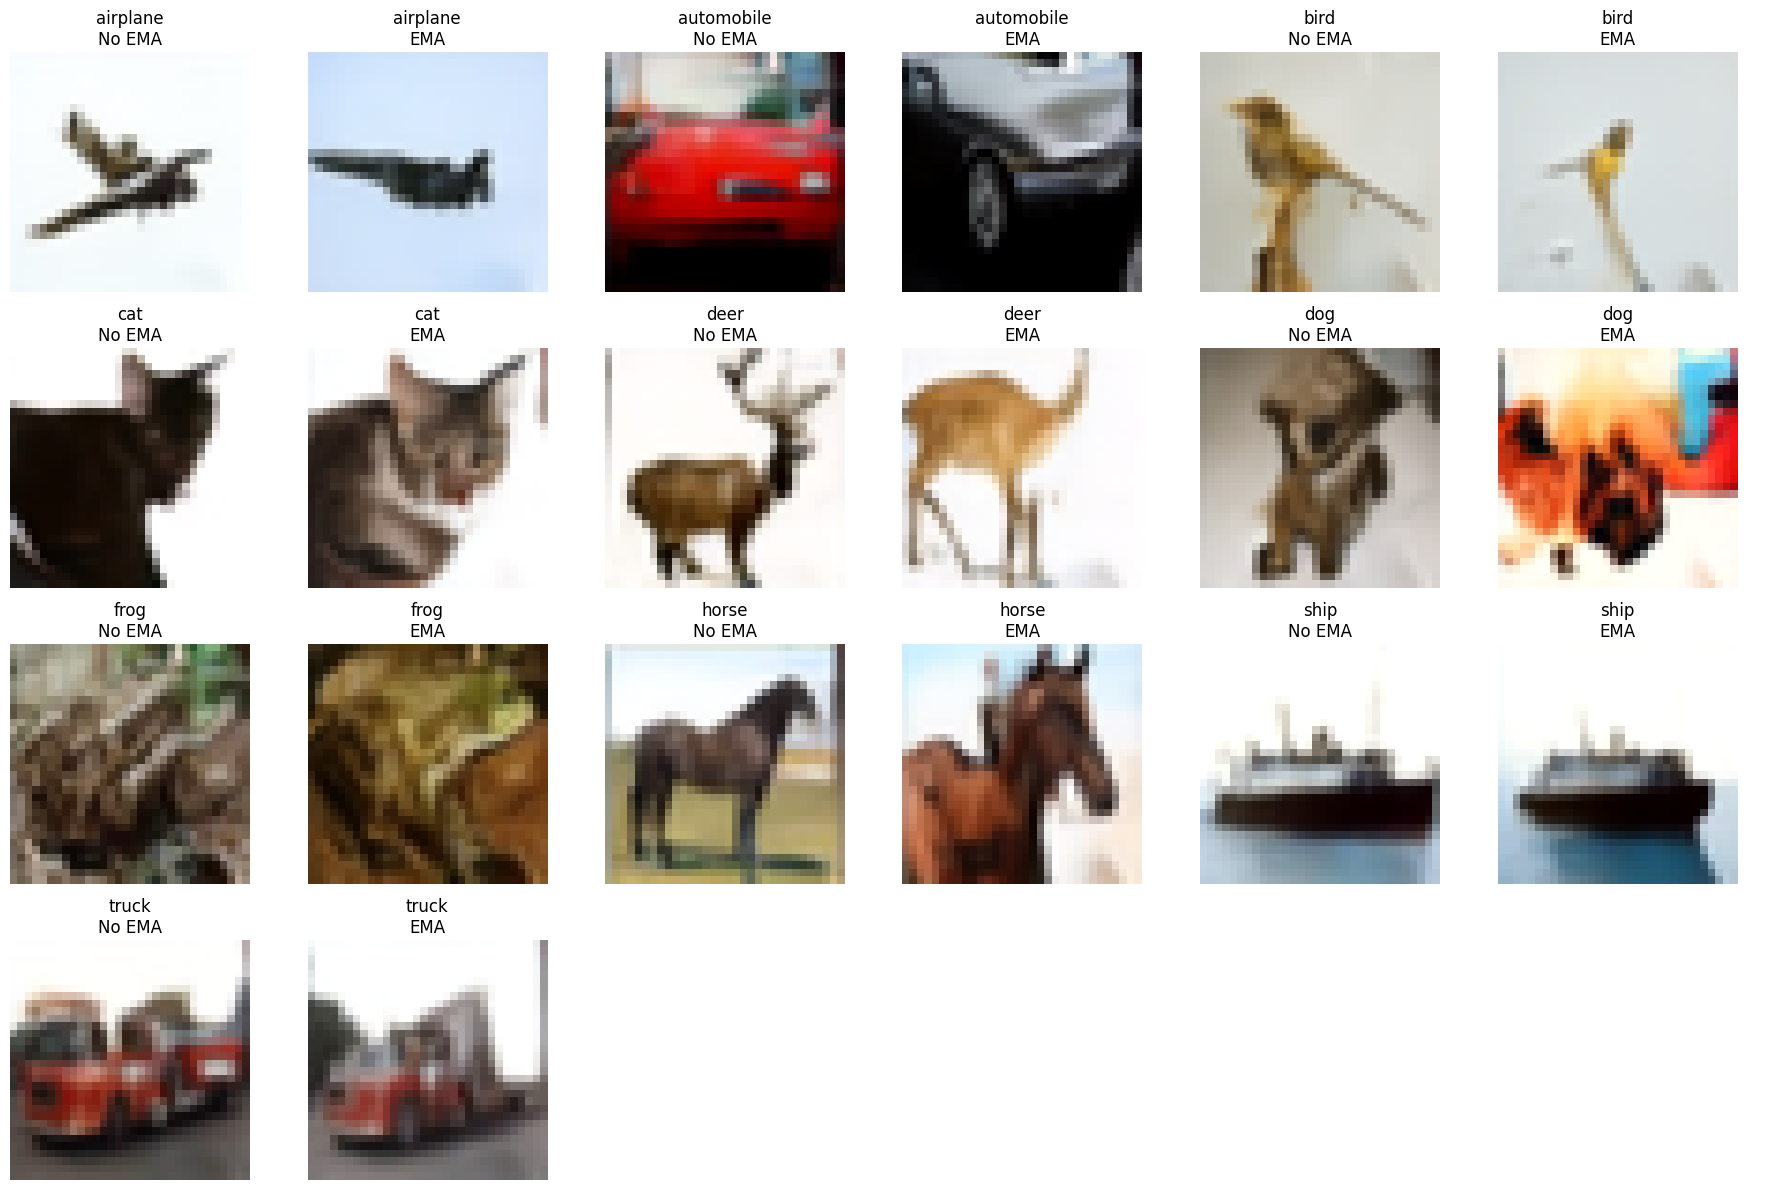

In [ ]:
compare_normal_vs_ema(
    model=loaded_model,
    ema=loaded_ema,
    get_sample_img=get_sample_img,
    timesteps=1000,
    sampling_timesteps=25,
    pred_type="v",
    sampler="ddim",
    guidance_scale=5,
    eta=0.8,
    seed=42,
)

In [ ]:
import numpy as np
import imageio.v2 as imageio
import torch


def make_sampling_gif(
    img_steps,
    save_path="sampling.gif",
    duration=0.30,
    loop=0,
):
    """
    Creates a GIF from diffusion sampling steps.

    Args:
        img_steps (list):
            List of images/tensors saved during sampling.

            Supported formats:
            - torch.Tensor (C,H,W) in [-1,1]
            - numpy array (H,W,C) uint8

        save_path (str):
            Path where gif will be saved.

        duration (float):
            Seconds per frame.

        loop (int):
            GIF loop count.
            0 = infinite loop.
    """

    frames = []

    for img in img_steps:

        # -------------------------
        # torch tensor case
        # -------------------------
        if isinstance(img, torch.Tensor):

            img = img.detach().cpu()

            # CHW -> HWC
            if img.ndim == 3 and img.shape[0] in [1, 3]:
                img = img.permute(1, 2, 0)

            img = img.numpy()

            # normalize from [-1,1] -> [0,255]
            if img.dtype != np.uint8:
                img = np.clip(img, -1, 1)
                img = ((img + 1) / 2) * 255
                img = img.astype(np.uint8)

        # -------------------------
        # numpy case
        # -------------------------
        elif isinstance(img, np.ndarray):

            if img.dtype != np.uint8:
                img = np.clip(img, -1, 1)
                img = ((img + 1) / 2) * 255
                img = img.astype(np.uint8)

        else:
            raise TypeError(
                f"Unsupported image type: {type(img)}"
            )

        frames.append(img)

    imageio.mimsave(
        save_path,
        frames,
        duration=duration,
        loop=loop,
    )

    print(f"GIF saved to: {save_path}")

In [ ]:
loaded_ema.apply_shadow()
img, img_steps = get_sample_img(
    model=loaded_model,
    img_shape=(1,3,32,32),
    timesteps=1000,
    sampling_timesteps=500,
    pred_type='v',
    c=8,
    sampler='ddim',
    guidance_scale=5,
    eta=0.8,
    plot_img=False,
    save_steps=True,
    seed=1994
)
loaded_ema.restore()

make_sampling_gif(
    img_steps,
    save_path="ddim_sampling.gif",
    duration=0.3
)

DDIM Reverse Process for 500 timesteps:   0%|          | 0/500 [00:00<?, ?it/s]

GIF saved to: ddim_sampling.gif


## Loss Curve

In [ ]:
checkpoint.keys()

dict_keys(['model_state_dict', 'optimizer_state_dict', 'ema_state_dict', 'epoch', 'pred_type', 'loss_hist', 'class_free_dropout', 'guidance_scale'])

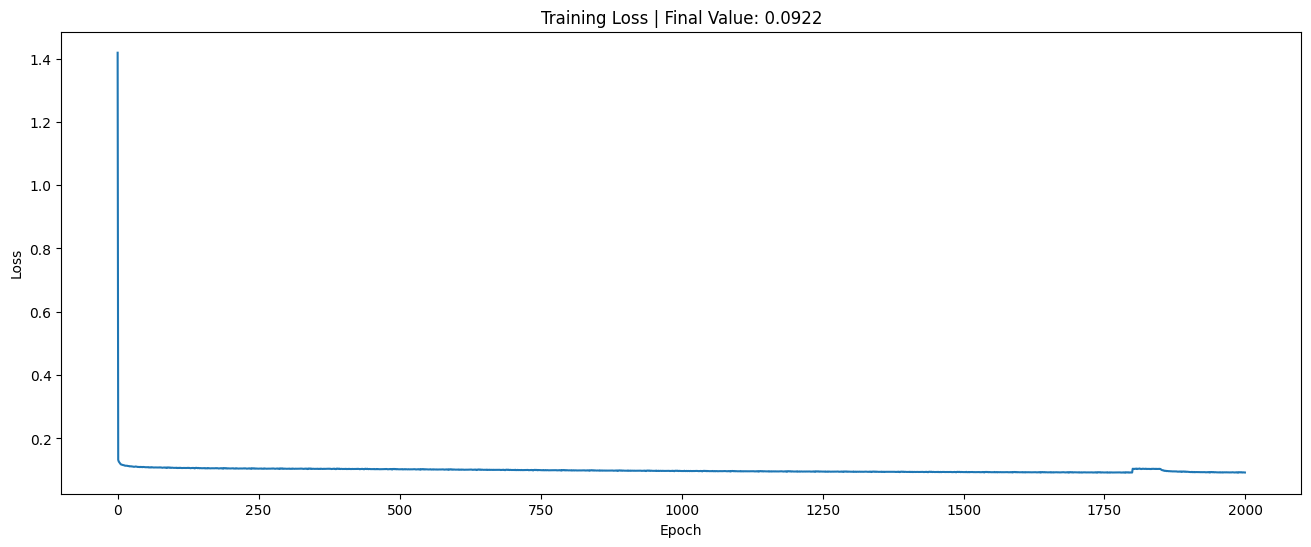

In [ ]:
loss_hist = checkpoint['loss_hist']
epoch = checkpoint['epoch']

fig, ax = plt.subplots(figsize = (16,6))
ax.plot(loss_hist)
ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")
ax.set_title(f"Training Loss | Final Value: {loss_hist[-1]:.4f}");

---

# FILES FOR GITHUB